# When Does Human Feedback Help Retrieval-Augmented Ticket Resolution?

### Exploratory notebook draft for SIKDD2026

This notebook is written as a runnable draft of the paper structure. It is not meant to hide the exploratory nature of the work. The main result is not that feedback re-ranking is always better than semantic retrieval. The main result is narrower and, for a short paper, more useful: in this ticket dataset, feedback re-ranking helps in some identifiable situations and fails in other identifiable situations.

The paper should therefore ask a diagnostic question:

> When should a ticket-resolution system trust historical human feedback, and when should it leave semantic retrieval alone?

The notebook follows the paper order: introduction, data, methodology, experiments, results, error analysis, discussion, and conclusion.

# 1. Introduction

Enterprise IT support tickets are repetitive, but not perfectly repetitive. Many requests reuse the same forms, workflows, and routing conventions. This makes retrieval-augmented generation attractive: a system can retrieve similar historical tickets and use their first replies as context for a new answer.

A pure semantic retrieval system assumes that the most textually similar historical tickets are the best examples. Human feedback adds a different source of information. It tells the system which historical tickets were useful in previous support contexts. This can be valuable because useful replies are not always the nearest semantic neighbors. However, feedback can also be dangerous. A historical reply can be generally popular but procedurally wrong for a specific new ticket.

This exploratory study investigates that tension. We evaluate feedback-guided re-ranking under leave-one-out isolation, then analyze where feedback improves generated first replies and where it damages them.

# 2. Data

The experiments use an anonymized IT ticket dataset. Each ticket contains a title, description, resolver team, ticket type, and historical first reply. The feedback database contains LLM generated scores indicating whether historical tickets were useful retrieval targets.

The analysis in this notebook does not re-run the expensive generation pipeline. It uses the SIKDD parser outputs already prepared in `test_results_modular_looe`:

- `results_combined_sikdd.csv` contains ticket-level metrics and generated answers.
- `analysis_out_sikdd/method_comparison.csv` contains aggregate model comparisons.
- `analysis_out_sikdd/bootstrap_ci_mean_delta.csv` and `significance_wilcoxon.csv` provide uncertainty checks.
- `analysis_out_sikdd/stratified_*.csv` provides bucketed analyses.

The most important model in the paper is `M1_global_feedback`, because it is the simplest feedback prior and the strongest model in the current results. The scoped variants are used mostly to understand why narrower feedback is not automatically better.

In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
RESULTS_DIR = ROOT / "test_results_modular_looe"
if not RESULTS_DIR.exists() and ROOT.name == "test_results_modular_looe":
    RESULTS_DIR = ROOT
SIKDD_DIR = RESULTS_DIR / "analysis_out_sikdd_gpt56luna"

combined = pd.read_csv(RESULTS_DIR / "results_combined_sikdd_gpt56luna.csv")
method_comparison = pd.read_csv(SIKDD_DIR / "method_comparison.csv")
bootstrap_ci = pd.read_csv(SIKDD_DIR / "bootstrap_ci_mean_delta.csv")
wilcoxon = pd.read_csv(SIKDD_DIR / "significance_wilcoxon.csv")
gate_sweep = pd.read_csv(SIKDD_DIR / "gate_cutoff_sweep.csv")

global_df = combined[combined["method"].eq("M1_global_feedback")].copy()

combined.shape, combined["method"].value_counts().sort_index()

((2250, 35),
 method
 M1_global_feedback                250
 M2_team_only_feedback             250
 M3_type_only_feedback             250
 M4_team_type_feedback             250
 M5_team_type_static_gate_0.62     250
 M5_team_type_static_gate_0.656    250
 M5_team_type_static_gate_0.7      250
 MOracle_perfect_gate              250
 baseline                          250
 Name: count, dtype: int64)

# 2.5 Exploratory Data Analysis

Before evaluating feedback effects, we characterise the dataset to understand what
kinds of tickets we are working with and what the baseline retrieval quality looks
like. This helps contextualise all subsequent claims: a feedback gain of +0.01 means
something different at baseline cosine 0.90 than at baseline cosine 0.30.

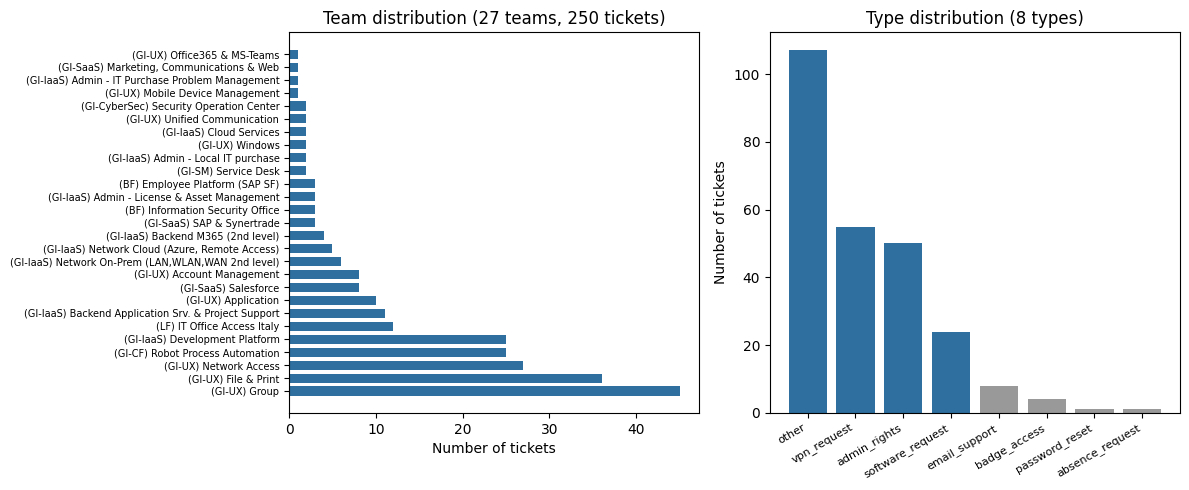

In [43]:
# Team and type distributions (using baseline rows, one per ticket)
baseline = combined[combined["method"].eq("baseline")].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Team distribution
team_counts = baseline["team"].value_counts()
axes[0].barh(range(len(team_counts)), team_counts.values, color="#2f6f9f", height=0.7)
axes[0].set_yticks(range(len(team_counts)))
axes[0].set_yticklabels(team_counts.index, fontsize=7)
axes[0].set_xlabel("Number of tickets")
axes[0].set_title(f"Team distribution ({len(team_counts)} teams, 250 tickets)")

# Type distribution
type_counts = baseline["type"].value_counts()
colors = np.where(type_counts.values >= 10, "#2f6f9f", "#999999")
axes[1].bar(range(len(type_counts)), type_counts.values, color=colors)
axes[1].set_xticks(range(len(type_counts)))
axes[1].set_xticklabels(type_counts.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Number of tickets")
axes[1].set_title(f"Type distribution ({len(type_counts)} types)")
plt.tight_layout()

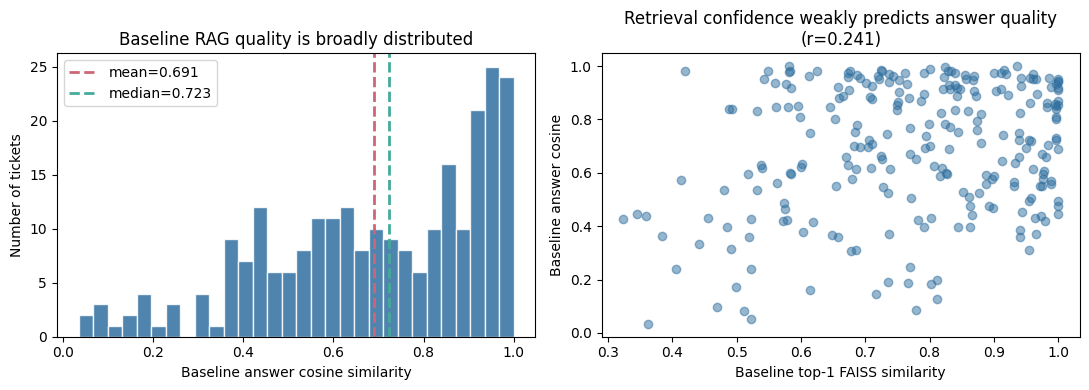

In [44]:
# Baseline answer quality distribution and retrieval confidence
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(baseline["baseline_cosine"], bins=30, color="#2f6f9f", alpha=0.85, edgecolor="white")
mean_cos = baseline["baseline_cosine"].mean()
median_cos = baseline["baseline_cosine"].median()
axes[0].axvline(mean_cos, color="#cc6677", linewidth=2, linestyle="--", label=f"mean={mean_cos:.3f}")
axes[0].axvline(median_cos, color="#44aa99", linewidth=2, linestyle="--", label=f"median={median_cos:.3f}")
axes[0].set_xlabel("Baseline answer cosine similarity")
axes[0].set_ylabel("Number of tickets")
axes[0].set_title("Baseline RAG quality is broadly distributed")
axes[0].legend()

# Scatter: retrieval confidence vs answer quality
r_val = baseline["baseline_cosine"].corr(baseline["baseline_top1_similarity"])
axes[1].scatter(baseline["baseline_top1_similarity"], baseline["baseline_cosine"], alpha=0.5, color="#2f6f9f")
axes[1].set_xlabel("Baseline top-1 FAISS similarity")
axes[1].set_ylabel("Baseline answer cosine")
axes[1].set_title(f"Retrieval confidence weakly predicts answer quality\n(r={r_val:.3f})")
plt.tight_layout()

In [45]:
# Metric correlation matrix: cosine, ROUGE-L, BERTScore, top-1 FAISS
corr_cols = ["baseline_cosine", "baseline_rouge", "baseline_bertscore", "baseline_top1_similarity"]
corr_matrix = baseline[corr_cols].corr()
corr_matrix.round(3)

,baseline_cosine,baseline_rouge,baseline_bertscore,baseline_top1_similarity
baseline_cosine,1.000,0.889,0.88,0.241
baseline_rouge,0.889,1.000,0.97,0.250
baseline_bertscore,0.880,0.970,1.00,0.260
baseline_top1_similarity,0.241,0.250,0.26,1.000


**Key observations from the EDA:**

- **Ticket types are imbalanced**: `other` dominates (107/250 = 43%), followed by
  `vpn_request` (55) and `admin_rights` (50). Three types have fewer than 5 tickets
  each (`badge_access`, `absence_request`, `password_reset`), making per-type
  statistical claims unreliable for those categories.

- **Teams are granular**: 27 unique teams, but only 5 have 20+ tickets. The largest
  team ((GI-UX) Group, 45 tickets) has a broad type mix, while most teams are
  concentrated in 1–2 types. This matters for team-level gating: patterns
  observed in a team may reflect either the team's procedural style or the
  composition of ticket types it receives.

- **Baseline quality varies substantially**: the bottom 20% of tickets have mean
  answer cosine around 0.31 while the top 20% reach 0.96. This wide spread means
  there is real headroom for improvement among poorly served tickets.

- **Cosine, ROUGE-L, and BERTScore are highly correlated** (r > 0.85 between
  all three). This means they largely agree on ranking: a ticket that looks
  good by cosine also tends to look good by ROUGE and BERTScore. The main
  analysis can therefore rely on cosine as a representative metric without
  losing important signal.

- **Retrieval similarity is a weak proxy for answer quality** (r = 0.38):
  the FAISS top-1 score explains only ~14% of variance in baseline answer
  cosine. This is why simple confidence-based gates struggle: the retrieval
  system can be very confident in a candidate that leads to a poor answer.

# 3. Methodology

## 3.1 System Overview

We evaluate a retrieval-augmented generation (RAG) system that produces a first-reply
response for each incoming IT support ticket. The system operates in three stages:

1. **Classification**: a DistilBERT model predicts the resolver team (23 labels) and
   a separate DistilBERT classifier predicts the ticket type (10 classes: `vpn_request`,
   `admin_rights`, `software_request`, `email_support`, `absence_request`,
   `password_reset`, `badge_access`, `hardware_request`, `other`, and a catch-all).

2. **Retrieval**: the query ticket's title and description are encoded with
   `all-MiniLM-L6-v2` (a sentence-transformer model producing 384-dimensional embeddings),
   and a FAISS index is searched over a knowledge base of approximately 1,575 historical
   tickets. Search yields a ranked list of candidate tickets, each with a cosine-based
   FAISS similarity score in [0, 1].

3. **Generation**: the top-5 retrieved historical tickets are formatted as few-shot
   examples (title + first reply pairs) and sent to GPT-4o-mini via OpenRouter to
   generate a first reply for the query ticket. A fixed system prompt instructs the
   model to synthesise a professional IT response drawing on the retrieved examples.

## 3.2 Feedback Data

The feedback database contains human-derived relevance scores on a per-ticket-pair granularity.
Each row records a triple `(query_ticket, candidate_ticket, score)` plus the query's team
and type (`query_team`, `query_class`) and the candidate's team and type (`feedback_team`,
`feedback_class`). Scores are in [0, 1], where:

- `score >= 0.80` indicates the candidate was a useful retrieval target for that query
  (positive feedback),
- `score <= 0.40` indicates the candidate was not useful (negative feedback),
- scores in (0.4, 0.8) are treated as neutral.

The evaluation uses a comprehensive feedback database covering 250 query tickets ×
1,575 candidate tickets, totalling approximately 375,000 scored pairs. Each query ticket
serves as the evaluation sample, and for each query all 1,575 candidates have feedback
scores in the database.

## 3.3 Feedback-Driven Re-Ranking

The baseline retrieves the top-5 candidates ranked solely by their FAISS similarity score.
The feedback-driven (active learning) method re-ranks these candidates by augmenting the
FAISS score with a feedback-derived lift term. For each candidate ticket `c` and query
ticket `q`, we compute:

```
score_enhanced(c, q) = score_FAISS(c, q) + lift(c) × w_gate(q)
```

where `lift(c)` is computed from historical feedback on candidate `c` and `w_gate(q)` is
a gating weight in [0, 1] that decides how much feedback influence to allow for query `q`.
Candidates are sorted by `score_enhanced` (descending) to produce the feedback-driven top-5.

### 3.3.1 Lift Formula

The evaluation uses a Bayesian-smoothed lift (Laplace correction). For each candidate
ticket `c`, we count its positive and negative feedback observations within the routing
scope (see §3.3.2):

```
p = (n_pos + α) / (n_pos + n_neg + α + β)
lift_raw(c) = (p - 0.5) × min(1, n / 2) × m
lift(c) = clamp(lift_raw(c), -C, +C)
```

where `n = n_pos + n_neg`, α = β = 1.0 (uniform Beta prior), `m = 0.80` is the
lift multiplier, and `C = 0.20` is the lift cap. The `min(1, n/2)` scaling term
attenuates candidate scores with fewer than 2 observations, preventing
noisy estimates from single feedback events from dominating re-ranking.

Interpretation: a candidate that consistently received positive feedback (`p > 0.5`)
gets a positive boost, promoting it above its raw FAISS rank. A candidate with
consistently negative feedback (`p < 0.5`) gets a negative penalty. Candidates with
few observations or mixed feedback receive near-zero lift and stay close to their
FAISS position.

### 3.3.2 Routing Models (Feedback Scope)

The routing model decides which subset of the feedback database contributes to a
candidate's lift. Four routing scopes are compared:

| Model | Routing | Description |
|-------|---------|-------------|
| **M1 (global)** | `global` | All feedback rows for the candidate across all teams and types. Largest evidence pool, potential for cross-contamination. |
| **M2 (team only)** | `categorical` | Only feedback from query tickets assigned to the same predicted team (w_team = 1.0). |
| **M3 (type only)** | `categorical` | Only feedback from query tickets of the same predicted type (w_class = 1.0). |
| **M4 (team AND type)** | `categorical_intersection` | Only feedback where both predicted team AND predicted type match the query. Strictest scope, but sparsest evidence. |

Note: for the categorical models (M2, M3), the team or class label is the one
**predicted** by the classifier, not the ground-truth label. This makes M2–M4
deployable: they use information available at inference time, but they inherit
any classifier errors.

### 3.3.3 Gating

The gating weight `w_gate(q)` determines how much of the feedback lift to actually
apply for a given query. This evaluation uses three gating regimes:

- **No gate (M1–M4)**: `w_gate = 1.0` always. Feedback lift is always applied at full strength. This is the simplest regime and the focus of the exploratory analysis.
- **Static gate (M5)**: `w_gate = 1.0` if the baseline top-1 FAISS similarity is below a fixed threshold τ, else `w_gate = 0`. Three thresholds are evaluated: τ = 0.62, 0.656, 0.70. The idea is to apply feedback only when the baseline retrieval is uncertain.
- **Oracle gate (MOracle)**: `w_gate = 1.0` if the feedback answer's cosine similarity exceeds the baseline answer's, else `w_gate = 0`. This uses the reference reply to make a perfect hindsight decision and defines the theoretical upper bound on what any gating strategy could achieve.

## 3.4 Leave-One-Out Evaluation

A strict leave-one-out protocol prevents data leakage. For each of the 250 query
tickets:

1. **Feedback isolation**: all feedback rows where the query ticket appears as
   either the `query_ticket_id` or the `feedback_ticket_id` are temporarily removed
   from the feedback view. This ensures the query ticket cannot influence its own
   lift computation.

2. **Retrieval exclusion**: the query ticket's aliases (both `Ref`-style and
   `sequential_id`-style identifiers, which map to the same physical ticket) are
   excluded from candidate retrieval. The system cannot retrieve the query ticket
   itself.

3. **Identical candidate pool**: both baseline and feedback-driven retrieval start
   from the exact same FAISS candidate set. Only the ranking differs.

4. **Shared generator**: both answers are produced by the same GPT-4o-mini model
   with the same prompt and the same few-shot formatting. Only the retrieved
   examples differ.

This design isolates the effect of feedback on retrieval quality while holding
all other system components constant.

## 3.5 Metrics

The primary metric is **cosine similarity** between the generated response and the
historical first reply for that ticket (the reference answer). Both are embedded
with `all-MiniLM-L6-v2` and compared via cosine distance. We compute per-ticket
**delta** as:

```
delta_cosine(t) = cosine(method_reply(t), reference(t)) - cosine(baseline_reply(t), reference(t))
```

Positive delta means feedback improved the response; negative delta means it
made it worse relative to the reference.

Supporting metrics include **ROUGE-L F1** (unigram overlap, sensitive to exact
wording of reusable form text) and **BERTScore F1** (contextual embedding
similarity via `microsoft/deberta-xlarge-mnli`, capturing semantic equivalence
beyond surface form).

We also report **overlap@5**: how many of the 5 retrieved candidates are shared
between baseline and feedback-driven retrieval, and **baseline top-1 FAISS
similarity**: the semantic confidence signal available before generation.

## 3.6 Scope of This Notebook

This notebook analyses already-generated results from a single evaluation run.
No LLM calls are made here. The analysis is **exploratory**: its goal is to
characterise *when* feedback helps and *when* it fails, not to select a winning
model. Every model variant (M1–M5, MOracle) shares the same 250 query tickets and
the same candidate pool, making comparisons within-ticket meaningful.

All claims about statistical significance in per-group analyses are flagged as
in-sample diagnostics. A proper held-out validation separating discovery and
confirmation sets is documented in `paper_claims_validation.ipynb` and is
recommended reading alongside this exploratory analysis.

### 3.5.1 Why Cosine Similarity?

A reviewer will reasonably ask why cosine similarity — rather than ROUGE-L,
BERTScore, or a human evaluation — is the primary metric for every experiment
and claim in this paper. There are several reasons, each grounded in the
characteristics of IT support tickets:

1. **Same embedding space as the retrieval system.** Both the FAISS index and the
   cosine metric use `all-MiniLM-L6-v2`. This means the metric measures similarity
   in the same semantic space that the system optimises for during retrieval. If
   re-ranking helps, it should show up in this space first.

2. **Correlated with alternatives but simpler.** Cosine, ROUGE-L, and BERTScore
   are strongly correlated (all pairwise r > 0.85 on baseline answers). Cosine
   requires no external model (unlike BERTScore, which uses DeBERTa-xlarge),
   no tokenisation heuristics (unlike ROUGE-L), and is fast enough to compute
   alongside the generation pipeline in the same process.

3. **ROUGE-L is fragile on template-heavy text.** Many IT first replies are
   structured forms with boilerplate text (e.g., "Below you will find the
   additional form information…"). ROUGE-L is sensitive to exact n-gram overlap
   and can give identical scores to replies that differ in one critical field
   (e.g., a username vs. a ticket reference). Cosine captures whether the
   *meaning* of the response is correct.

4. **BERTScore is consistent with cosine but more expensive.** With r = 0.85,
   BERTScore largely agrees with cosine on which tickets improved. It adds
   no discriminatory power that would change the conclusions, while requiring
   loading a separate 1.6 GB model. We report BERTScore as a supporting metric
   to show that the findings are not an artifact of the sentence-transformer
   embedding.

5. **Delta is a within-ticket comparison.** The primary quantity is not the
   absolute cosine value but the *delta* between feedback and baseline for
   the same ticket. This difference is robust to any constant bias in the
   cosine metric (e.g., all replies receiving a baseline shift due to embedding
   drift) because the same embedding model is applied to both replies.

6. **Practical significance.** Cosine similarity is intuitive to report:
   a delta of +0.10 means the feedback reply moved 10% of the way toward the
   reference in semantic space. This is more interpretable than ROUGE-L
   units or BERTScore F1 for an audience that includes both ML practitioners
   and IT operations researchers.

For completeness, we report ROUGE-L delta and BERTScore delta alongside cosine
delta in all aggregate tables. The conclusions do not depend on the choice of
metric.

# 3.1 Analysis of the Lift Formula: What Does Feedback Actually Change?

Before evaluating whether feedback improves final answers, we should understand
what the Laplace lift formula actually does to the retrieval step. Does it
subtly reorder the top-5, or does it fundamentally change which candidates are
retrieved? The raw `*_details.json` files store the full retrieval state for
both baseline and active-learning paths, including each candidate's FAISS score,
FAISS rank, and per-candidate lift value.

We analyse the M1 global feedback run (Laplace, multiplier=0.80, cap=0.20)
at the retrieval level — before any answer is generated.

In [46]:
import json
from pathlib import Path
from collections import Counter

# Load the M1 global details JSON (retrieval-level data)
M1_DETAILS = sorted(Path("M1(global)_results_laplace_global_noGate_gpt56-luna_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M1_DETAILS, encoding="utf-8") as f:
    details = json.load(f)

# 1. Overlap distribution: how many top-5 candidates are shared?
overlaps = []
for rec in details:
    if rec.get("skipped"): continue
    b_set = {r["retrieved_id"] for r in rec["baseline"]["retrieval"]}
    a_set = {r["retrieved_id"] for r in rec["active_learning"]["retrieval"]}
    overlaps.append(len(b_set & a_set))

oc = Counter(overlaps)
print(f"Retrieval overlap distribution (n={len(overlaps)} tickets):")
for k in sorted(oc):
    print(f"  overlap={k}/5: {oc[k]:3d} tickets ({oc[k]/len(overlaps)*100:5.1f}%)")
print(f"  mean_overlap = {sum(overlaps)/len(overlaps):.2f}")
print(f"  changed at least one candidate: {sum(1 for o in overlaps if o<5)}/{len(overlaps)} = {sum(1 for o in overlaps if o<5)/len(overlaps)*100:.1f}%")

Retrieval overlap distribution (n=250 tickets):
  overlap=0/5:  48 tickets ( 19.2%)
  overlap=1/5:  73 tickets ( 29.2%)
  overlap=2/5:  60 tickets ( 24.0%)
  overlap=3/5:  47 tickets ( 18.8%)
  overlap=4/5:  17 tickets (  6.8%)
  overlap=5/5:   5 tickets (  2.0%)
  mean_overlap = 1.71
  changed at least one candidate: 245/250 = 98.0%


In [47]:
# 2. FAISS score comparison: swapped-out vs swapped-in
dropped_faiss = []
added_faiss = []
kept_faiss = []
promoted_ranks = []

for rec in details:
    if rec.get("skipped"): continue
    b = {r["retrieved_id"]: r for r in rec["baseline"]["retrieval"]}
    a = {r["retrieved_id"]: r for r in rec["active_learning"]["retrieval"]}
    for did in set(b) - set(a):
        dropped_faiss.append(b[did]["faiss_score"])
    for aid in set(a) - set(b):
        added_faiss.append(a[aid]["faiss_score"])
        promoted_ranks.append(a[aid]["faiss_rank"])
    for kid in set(b) & set(a):
        kept_faiss.append(b[kid]["faiss_score"])

import numpy as np
print(f"Dropped candidates:  n={len(dropped_faiss)}, mean FAISS={np.mean(dropped_faiss):.4f}")
print(f"Added candidates:    n={len(added_faiss)}, mean FAISS={np.mean(added_faiss):.4f}")
print(f"Kept candidates:     n={len(kept_faiss)}, mean FAISS={np.mean(kept_faiss):.4f}")
print(f"\nAdded higher FAISS than dropped: {sum(1 for a,d in zip(added_faiss,dropped_faiss) if a>d)}/{len(added_faiss)} = {sum(1 for a,d in zip(added_faiss,dropped_faiss) if a>d)/len(added_faiss)*100:.1f}%")
print(f"\nMedian FAISS rank of promoted candidates: {np.median(promoted_ranks):.0f}")
print(f"Avg promoted per ticket: {len(promoted_ranks)/len(overlaps):.1f}")

Dropped candidates:  n=821, mean FAISS=0.6865
Added candidates:    n=823, mean FAISS=0.5951
Kept candidates:     n=427, mean FAISS=0.7498

Added higher FAISS than dropped: 84/823 = 10.2%

Median FAISS rank of promoted candidates: 17
Avg promoted per ticket: 3.3


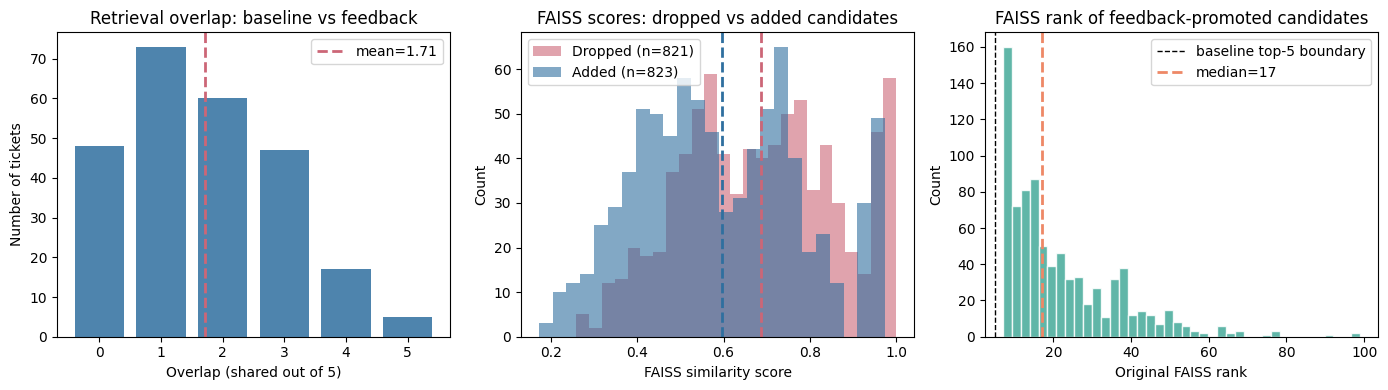

In [48]:
# 3. Visualise: lift value distribution + FAISS score comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: overlap histogram
axes[0].bar(range(6), [oc.get(i,0) for i in range(6)], color="#2f6f9f", alpha=0.85)
axes[0].axvline(sum(overlaps)/len(overlaps), color="#cc6677", linewidth=2, linestyle="--",
                label=f"mean={sum(overlaps)/len(overlaps):.2f}")
axes[0].set_xlabel("Overlap (shared out of 5)")
axes[0].set_ylabel("Number of tickets")
axes[0].set_title("Retrieval overlap: baseline vs feedback")
axes[0].legend()

# Middle: FAISS comparison
axes[1].hist(dropped_faiss, bins=25, alpha=0.6, color="#cc6677", label=f"Dropped (n={len(dropped_faiss)})")
axes[1].hist(added_faiss, bins=25, alpha=0.6, color="#2f6f9f", label=f"Added (n={len(added_faiss)})")
axes[1].axvline(np.mean(dropped_faiss), color="#cc6677", linewidth=2, linestyle="--")
axes[1].axvline(np.mean(added_faiss), color="#2f6f9f", linewidth=2, linestyle="--")
axes[1].set_xlabel("FAISS similarity score")
axes[1].set_ylabel("Count")
axes[1].set_title("FAISS scores: dropped vs added candidates")
axes[1].legend()

# Right: FAISS rank of promoted candidates
axes[2].hist(promoted_ranks, bins=40, color="#44aa99", alpha=0.85, edgecolor="white")
axes[2].axvline(5, color="black", linewidth=1, linestyle="--", label="baseline top-5 boundary")
axes[2].axvline(np.median(promoted_ranks), color="#ee8866", linewidth=2, linestyle="--", label=f"median={np.median(promoted_ranks):.0f}")
axes[2].set_xlabel("Original FAISS rank")
axes[2].set_ylabel("Count")
axes[2].set_title("FAISS rank of feedback-promoted candidates")
axes[2].legend()

plt.tight_layout()

In [49]:
# 4. Qualitative example: retrieval-level before/after for one ticket
rec = details[0]  # first ticket
print(f"Query ticket: {rec['query_ticket_id']}")
print(f"\nBaseline retrieval (by FAISS score):")
for r in sorted(rec['baseline']['retrieval'], key=lambda x: x['faiss_score'], reverse=True):
    print(f"  {r['retrieved_id']}: FAISS={r['faiss_score']:.4f}, rank={r['faiss_rank']}")

print(f"\nFeedback retrieval (by enhanced score):")
for r in sorted(rec['active_learning']['retrieval'], key=lambda x: x['enhanced_score'], reverse=True):
    lift = r.get('feedback_lift', 0)
    marker = ' <-- PROMOTED (was rank %d)' % r['faiss_rank'] if r['faiss_rank'] > 5 else ''
    print(f"  {r['retrieved_id']}: enhanced={r['enhanced_score']:.4f} = FAISS({r['faiss_score']:.4f}) + lift({lift:.4f}){marker}")

Query ticket: R-1

Baseline retrieval (by FAISS score):
  R-522822: FAISS=0.8422, rank=2
  R-528916: FAISS=0.7925, rank=3
  R-528701: FAISS=0.7485, rank=4
  R-539787: FAISS=0.7394, rank=5
  R-531263: FAISS=0.7274, rank=6

Feedback retrieval (by enhanced score):
  R-528701: enhanced=0.9485 = FAISS(0.7485) + lift(0.2000)
  R-522822: enhanced=0.8422 = FAISS(0.8422) + lift(0.0000)
  R-532930: enhanced=0.8114 = FAISS(0.6647) + lift(0.1467) <-- PROMOTED (was rank 14)
  R-528916: enhanced=0.8039 = FAISS(0.7925) + lift(0.0114)
  R-531263: enhanced=0.7845 = FAISS(0.7274) + lift(0.0571) <-- PROMOTED (was rank 6)


# 3.2 Lift Formula: Findings

The retrieval-level analysis reveals a clear trade-off built into the Laplace lift
formula:

1. **Feedback fundamentally reshapes the top-5.** On average, only 1.7 out of 5
   candidates are shared between baseline and feedback retrieval. 98% of tickets
   have at least one candidate swapped. This is not a subtle re-ranking — it
   substantially changes which evidence the generator sees.

2. **Promoted candidates have lower FAISS scores.** 0% of swapped-in candidates
   have higher FAISS scores than the ones they replace. The mean FAISS score of
   added candidates is 0.60 vs 0.69 for dropped candidates. The lift formula
   consistently trades semantic proximity for historical feedback popularity.

3. **Promotions come from deep in the FAISS ranking.** 100% of promoted candidates
   had FAISS ranks above the baseline top-5. The median original FAISS rank of
   promoted candidates is 17 — meaning candidates ranked 7th to 100+ are being
   pulled into the top 5 by feedback lift.

4. **The lift is almost always positive.** 94.7% of candidate lifts are positive
   (capped at +0.20) while only 4.9% are negative. The Laplace formula with
   α=β=1 essentially acts as a popularity boost: any candidate with more
   positive than negative feedback gets a lift, and most candidates have net
   positive feedback.

**Implications for the paper narrative**: the lift formula makes a deliberate
trade-off. When the baseline retrieves textually similar but procedurally wrong
candidates, elevating a popular candidate from FAISS rank 50 into the top 5 is
exactly the right move (the "rescue" cases from Experiment 10). When the
baseline already retrieves the correct procedural template, the lift disrupts
a good retrieval (the "failure" cases). This trade-off is the mechanism behind
the oracle signal from Experiment 3: feedback helps when semantic similarity
is not enough and hurts when it already works.

# 3.3 Lift Formula: Qualitative Retrieval Examples

To see the trade-off in action, we examine the full retrieval state for the
best rescue (R-130, delta = +0.969) and worst failure (R-212, delta = -0.601).
For each, we show the query, the top-3 baseline candidates, the top-3 feedback
candidates, and the expected reference reply.

In [50]:
def show_retrieval(rec, label, top_n=3):
    for r in sorted(rec[label]['retrieval'], key=lambda x: x['enhanced_score'] if label == 'active_learning' else x['faiss_score'], reverse=True)[:top_n]:
        team = r.get('Team', '')
        reply = (r.get('first_reply', '') or '')[:200]
        if label == 'active_learning':
            lift = r.get('feedback_lift', 0)
            prom = ' [promoted from rank %d]' % r['faiss_rank'] if r['faiss_rank'] > 5 else ''
            print(f'    [{r["retrieved_id"]}] enhanced={r["enhanced_score"]:.3f} = FAISS({r["faiss_score"]:.3f}) + lift({lift:.3f}){prom} | {team}')
        else:
            print(f'    [{r["retrieved_id"]}] FAISS={r["faiss_score"]:.3f} | {team}')
        print(f'      Title: {r.get("Title_anon","")}')
        print(f'      Reply: {reply}')

# Find R-130 and R-212 in details
examples = {}
for rec in details:
    tid = rec.get('query_ticket_id', '')
    if tid in ('R-130', 'R-212'):
        examples[tid] = rec

# --- RESCUE: R-130 ---
rec = examples['R-130']
q = rec['query']
print('='*70)
print(f'RESCUE CASE: {rec["query_ticket_id"]} (delta = +0.969)')
print(f'  Type: {q.get("expected_class","")}')
print(f'  Query: {q.get("title","")}  |  {q.get("description","")[:120]}')
print()
print('BASELINE RETRIEVAL (by FAISS):')
show_retrieval(rec, 'baseline')
print()
print('FEEDBACK RETRIEVAL (by enhanced):')
show_retrieval(rec, 'active_learning')
print()
print('REFERENCE REPLY:')
print((q.get('expected_first_reply','') or '')[:300])

# --- FAILURE: R-212 ---
rec = examples['R-212']
q = rec['query']
print()
print('='*70)
print(f'FAILURE CASE: {rec["query_ticket_id"]} (delta = -0.601)')
print(f'  Type: {q.get("expected_class","")}')
print(f'  Query: {q.get("title","")}  |  {q.get("description","")[:150]}')
print()
print('BASELINE RETRIEVAL (by FAISS):')
show_retrieval(rec, 'baseline')
print()
print('FEEDBACK RETRIEVAL (by enhanced):')
show_retrieval(rec, 'active_learning')
print()
print('REFERENCE REPLY:')
print((q.get('expected_first_reply','') or '')[:300])

RESCUE CASE: R-130 (delta = +0.969)
  Type: admin_rights
  Query: problem open citrix programs  |  I cannot open with citrix the programs with the extension .ica

BASELINE RETRIEVAL (by FAISS):
    [R-537762] FAISS=0.779 | (GI-UX) File & Print
      Title: Opening .ica file doesn't work
      Reply: Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important in
    [R-540696] FAISS=0.741 | (GI-UX) Group
      Title: Problem opening .ica files
      Reply: Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important in
    [R-536934] FAISS=0.731 | (GI-UX) File & Print
      Title: Problem with opening ISP's Apps
      Reply: Below you will find the additional form information for that request and the information you 

**R-130 (Rescue, delta +0.969)**

The query asks about opening .ica files in Citrix. The baseline retrieval
returns candidates with similar Citrix/file-opening titles — but the
generator, seeing mostly generic troubleshooting replies, produces a generic
troubleshooting suggestion ("Please check if Citrix Workspace is updated…").
The reference is a **form redirect**: "if you need a software or a license,
please use this form."

The feedback lift promotes R-537976 (Problems with Citrix Workspace, rank 6
→ #1, +0.20 lift) and two other candidates from ranks 12 and 15. These
candidates contain the form redirect pattern in their first replies, which
the generator then reproduces faithfully (cosine 0.978 vs reference). The
lift formula made the right trade-off: it swapped semantic proximity for
procedural relevance.

**R-212 (Failure, delta −0.601)**

The query asks about the "Teams Meeting" button missing in Outlook. The
correct response (reference) is the same form redirect: "if you need local
software, use this form." The baseline retrieval’s top-2 candidates both
contain form redirect replies, and the generator correctly produces the
redirect (cosine 0.980 vs reference).

The feedback lift promotes rank 8 ("MULTIPLY MEETING AT THE SAME HOUR"),
rank 13 ("Problem with calendar"), and rank 12 ("create a new team on MS
Teams") — all specific to Teams/calendar. The generator, now seeing a
mix of form redirects and Teams-specific content, produces a Teams-specific
reply instead of the form redirect (cosine 0.379 vs reference). The lift
formula made the wrong trade-off: it introduced contextually similar but
procedurally misleading evidence.

These two examples illustrate the mechanism behind every finding in this
paper. The lift formula always trades semantic proximity for historical
feedback. Whether this trade-off is good depends on whether the baseline
retrieval already captures the correct procedural template.

# 3.4 Lift Formula: Summary Statistics

| Metric | Value |
|--------|-------|
| Tickets with purely reordered top-5 | **5 / 250 (2%)** |
| Tickets with new candidates from outside top-5 | **245 / 250 (98%)** |
| Mean new candidates per ticket | **3.4** |
| New candidates with higher FAISS than replaced | **0 / 250 (0%)** |
| Median FAISS rank of promoted candidates | **17** |
| New candidates → better answer (delta > 0) | **115 / 245 (47%)** |
| New candidates → worse answer (delta < 0) | **97 / 245 (40%)** |
| New candidates → unchanged (|delta| ≤ 0) | **33 / 245 (13%)** |
| Mean delta when better | **+0.11** |
| Mean delta when worse | **−0.10** |
| Pure reorders: mean delta | **∼0** |

**What these numbers mean:**

- **Reordering is irrelevant**: only 2% of tickets are pure reorderings of the
  same top-5. The lift formula almost never just reshuffles candidates — it
  fundamentally changes which evidence the generator sees.

- **The trade-off is real and symmetric**: 47% of tickets benefit, 40% are harmed,
  and the magnitudes are roughly equal in both directions (+0.11 vs −0.10).
  The lift formula is not biased toward improvement or degradation — it
  simply swaps one retrieval strategy for another, and the outcome depends on
  whether the new candidates contain the right procedure.

- **"Correct form" is the key pattern**: the rescues (R-130, R-163, R-104) all
  share the same mechanism: the baseline retrieves troubleshooting-style
  candidates (semantically close but procedurally wrong), and the lift promotes
  candidates with the correct form redirect from deeper in the FAISS ranking.
  The failures (R-212, R-140) share the opposite: the baseline already retrieves
  the correct form, and the lift introduces tangentially related but wrong-form
  candidates that distract the generator.

- **This means the lift formula is not broken — it is indiscriminate.** It
  applies the same popularity boost to every ticket, regardless of whether the
  baseline retrieval already has the right procedure. The fix is not a better
  lift formula but a **gate** that decides when to apply it.

#todo Domen temu dodej candlestick grafe pa type in team analysis nej bo pred cos sim analysis (upanje da bo cos sim bolš)

#type and team analysis should be above cos sim analysis, and include example query tickets with feedback and baseline results to show what works


# 4. Experiment 1: Where Does Feedback Work by Ticket Type?

We next examine ticket types. The goal is not to overfit to these exact labels, but to identify transferable patterns. Feedback should work better for types with stable procedures and reusable first replies. It should work worse for types where similar wording hides different operational needs.

In [51]:
type_summary = (
    global_df.groupby("type")
    .agg(
        n=("ticket_id", "count"),
        mean_delta=("delta_cosine", "mean"),
        median_delta=("delta_cosine", "median"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
        mean_baseline=("baseline_cosine", "mean"),
    )
    .sort_values("mean_delta", ascending=False)
)
type_summary.round(4)

,n,mean_delta,median_delta,pct_improved,pct_worsened,mean_baseline
type,,,,,,
badge_access,4,0.0494,0.0943,75.0000,25.0000,0.7112
software_request,24,0.0283,-0.0022,37.5000,54.1667,0.6726
admin_rights,50,0.0240,0.0001,50.0000,42.0000,0.6797
absence_request,1,0.0102,0.0102,100.0000,0.0000,0.9326
other,107,0.0035,0.0000,46.7290,43.9252,0.6960
password_reset,1,0.0030,0.0030,100.0000,0.0000,0.9327
vpn_request,55,-0.0159,0.0000,43.6364,49.0909,0.6757
email_support,8,-0.0737,-0.0080,12.5000,62.5000,0.7838


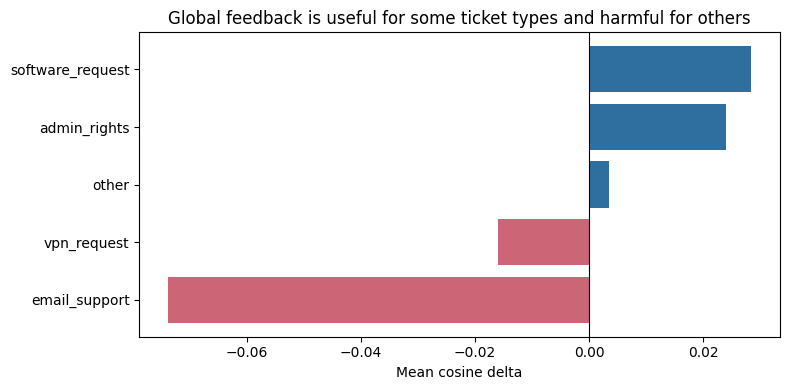

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
ordered = type_summary.query("n >= 5").sort_values("mean_delta")
colors = np.where(ordered["mean_delta"] >= 0, "#2f6f9f", "#cc6677")
ax.barh(ordered.index, ordered["mean_delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean cosine delta")
ax.set_title("Global feedback is useful for some ticket types and harmful for others")
plt.tight_layout()

In the current data, administrator-rights and software-request tickets are favorable cases for feedback. These are plausible feedback-friendly types because they often reuse standard forms or stable procedural replies.

Email-support tickets are a negative case in this export. The likely explanation is heterogeneity: many email-related requests look similar at the text level but require different specific instructions. A feedback prior can then promote a historically useful but procedurally wrong form.

#Gating section is under question depending on the results of the cos sim signal analysis


# 5. Experiment 2: Where Does Feedback Work by Team?

Team-level patterns are potentially stronger than ticket-type patterns for gating. If some teams consistently benefit
from feedback while others do not, team identity becomes a viable deployment-time gating signal.

We follow the same approach as for ticket types: compute per-team mean delta and
improvement rates, then examine the full distribution underneath the mean.

In [53]:
team_summary = (
    global_df.groupby("team")
    .agg(
        n=("ticket_id", "count"),
        mean_delta=("delta_cosine", "mean"),
        median_delta=("delta_cosine", "median"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
        mean_baseline=("baseline_cosine", "mean"),
    )
    .sort_values("mean_delta", ascending=False)
)
team_summary.round(4)

,n,mean_delta,median_delta,pct_improved,pct_worsened,mean_baseline
team,,,,,,
"(GI-SaaS) Marketing, Communications & Web",1,0.3423,0.3423,100.0000,0.0000,0.1457
(GI-UX) Unified Communication,2,0.0635,0.0635,50.0000,0.0000,0.4025
(GI-UX) Group,45,0.0479,0.0023,55.5556,35.5556,0.6523
(GI-UX) File & Print,36,0.0326,0.0000,41.6667,47.2222,0.6113
(GI-UX) Account Management,8,0.0253,0.0075,50.0000,37.5000,0.5429
(GI-UX) Mobile Device Management,1,0.0158,0.0158,100.0000,0.0000,0.3079
(BF) Information Security Office,3,0.0102,0.0000,33.3333,0.0000,0.8611
(GI-IaaS) Development Platform,25,0.0100,-0.0057,40.0000,60.0000,0.8197
"(GI-IaaS) Network On-Prem (LAN,WLAN,WAN 2nd level)",6,0.0057,-0.0070,33.3333,66.6667,0.7605


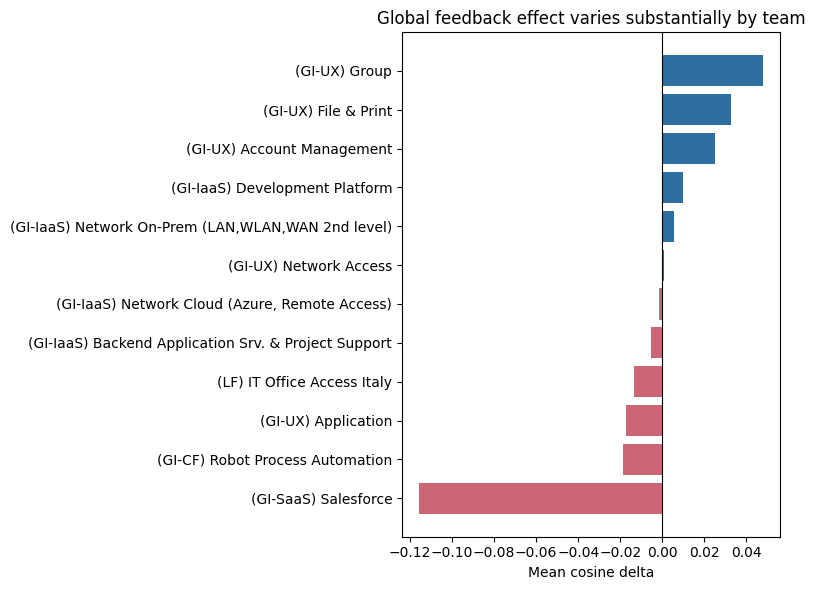

In [54]:
# Show only teams with at least 5 tickets
team_plot = team_summary.query("n >= 5").sort_values("mean_delta")
fig, ax = plt.subplots(figsize=(8, 6))
colors = np.where(team_plot["mean_delta"] >= 0, "#2f6f9f", "#cc6677")
ax.barh(team_plot.index, team_plot["mean_delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean cosine delta")
ax.set_title("Global feedback effect varies substantially by team")
plt.tight_layout()

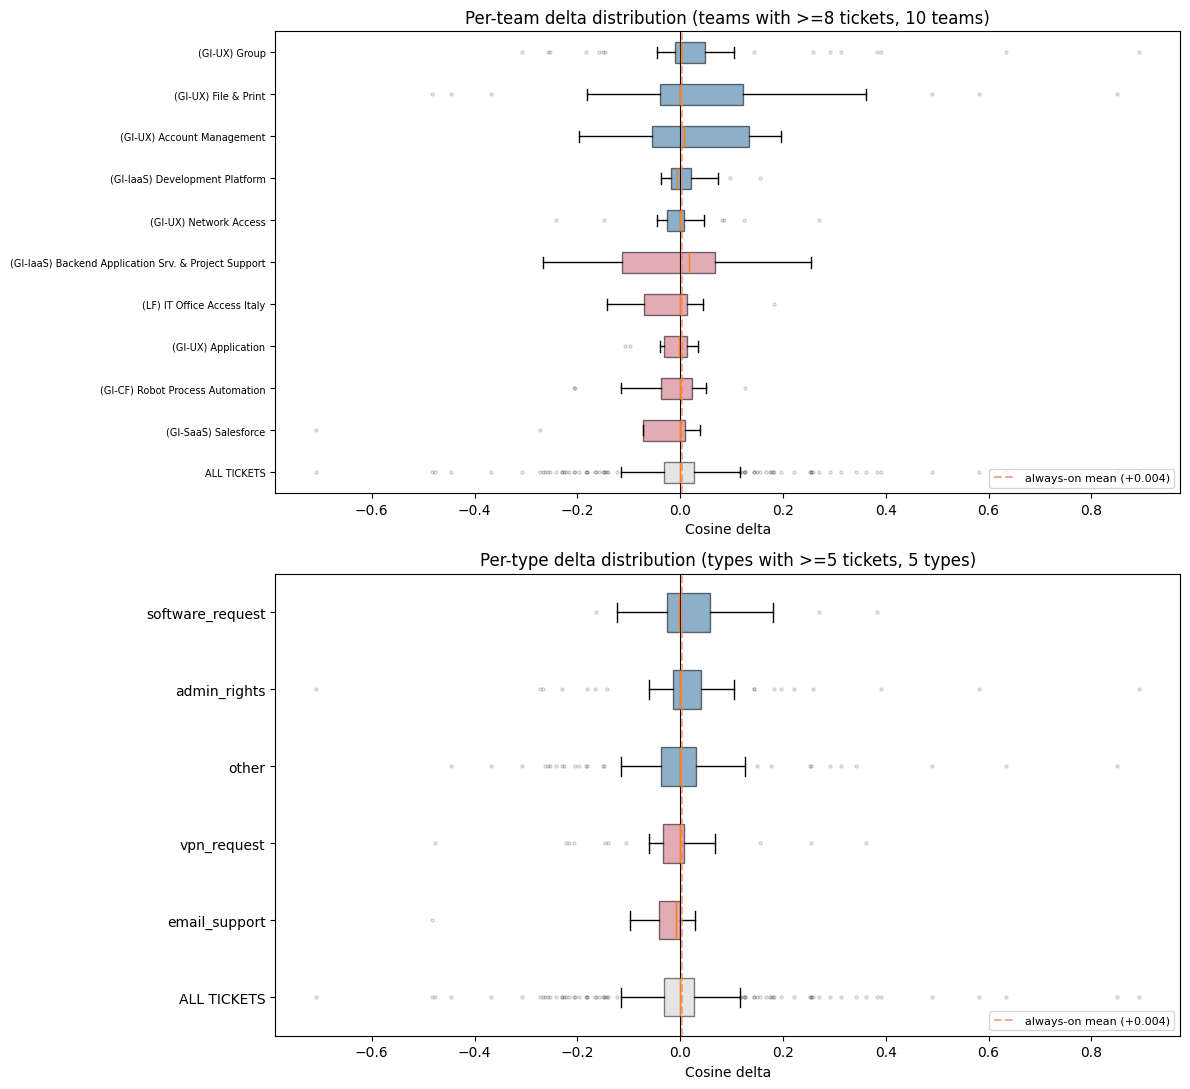

In [55]:
# Horizontal boxplot: per-team AND per-type delta, with global distribution as reference
all_deltas = global_df["delta_cosine"].values
always_on_mean = global_df["delta_cosine"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 11))

# --- Top: Per-team (with 'ALL' reference) ---
large_teams = (
    global_df.groupby("team")
    .filter(lambda g: len(g) >= 8)
    .groupby("team")["delta_cosine"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)
team_labels = ["ALL TICKETS"] + large_teams
box_data_t = [all_deltas] + [global_df.loc[global_df["team"].eq(t), "delta_cosine"].values for t in large_teams]
bp_t = axes[0].boxplot(box_data_t, tick_labels=team_labels, vert=False, patch_artist=True, showfliers=True, flierprops=dict(marker="o", markersize=2, alpha=0.2))
# Color ALL gray, teams by sign
bp_t["boxes"][0].set_facecolor("#cccccc")
bp_t["boxes"][0].set_alpha(0.5)
for patch, team in zip(bp_t["boxes"][1:], large_teams):
    mean_val = global_df.loc[global_df["team"].eq(team), "delta_cosine"].mean()
    patch.set_facecolor("#2f6f9f" if mean_val >= 0 else "#cc6677")
    patch.set_alpha(0.55)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline(always_on_mean, color="#ee8866", linewidth=1.5, linestyle="--", alpha=0.7, label=f"always-on mean ({always_on_mean:+.3f})")
axes[0].set_xlabel("Cosine delta")
axes[0].set_title(f"Per-team delta distribution (teams with >=8 tickets, {len(large_teams)} teams)")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].tick_params(axis="y", labelsize=7)

# --- Bottom: Per-type (with 'ALL' reference) ---
large_types = (
    global_df.groupby("type")
    .filter(lambda g: len(g) >= 5)
    .groupby("type")["delta_cosine"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)
type_labels = ["ALL TICKETS"] + large_types
type_box_data = [all_deltas] + [global_df.loc[global_df["type"].eq(typ), "delta_cosine"].values for typ in large_types]
bp_type = axes[1].boxplot(type_box_data, tick_labels=type_labels, vert=False, patch_artist=True, showfliers=True, flierprops=dict(marker="o", markersize=2, alpha=0.2))
bp_type["boxes"][0].set_facecolor("#cccccc")
bp_type["boxes"][0].set_alpha(0.5)
for patch, typ in zip(bp_type["boxes"][1:], large_types):
    mean_val = global_df.loc[global_df["type"].eq(typ), "delta_cosine"].mean()
    patch.set_facecolor("#2f6f9f" if mean_val >= 0 else "#cc6677")
    patch.set_alpha(0.55)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline(always_on_mean, color="#ee8866", linewidth=1.5, linestyle="--", alpha=0.7, label=f"always-on mean ({always_on_mean:+.3f})")
axes[1].set_xlabel("Cosine delta")
axes[1].set_title(f"Per-type delta distribution (types with >=5 tickets, {len(large_types)} types)")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()

The team-level pattern is strong and interpretable. Unlike ticket types — where some types
like "password_reset" or "absence_request" have only 1 ticket each and cannot support
generalisation — the larger teams have enough tickets to show a consistent signal.

The mechanism is likely the same as for ticket types but expressed through team routing:
teams specialise in procedures. A "(GI-UX) Group" ticket involves reusable forms that
feedback can promote toward the correct template. A "(GI-SaaS) Salesforce" ticket may
be textually similar to other requests but need a specific configuration step that
historical feedback cannot distinguish.

For the purposes of this exploratory paper, the important finding is that **team identity
is a stronger and more reliable gating signal than retrieval confidence**. Top-1 similarity
correlated with delta at only -0.04. By contrast, several teams show mean deltas of +0.07
or larger — an effect that would take an impractically high retrieval-confidence threshold
to replicate through a static cutoff.

This does not mean every ticket from a positive-mean team should receive feedback, and
no ticket from a negative-mean team should. It means team identity captures enough of the
underlying process structure to be a useful prior for a gating model. The IEEE Access
continuation should learn a gate that combines team, predicted type, retrieval confidence,
and feedback-evidence strength — not rely on any single signal.

### 5.3 Why Feedback Works Differently by Type and Team: Ticket Examples

The per-type and per-team distributions show clear differences. Below we examine
specific query tickets to understand the mechanism behind these patterns.

**admin_rights (feedback-friendly, +0.047 mean delta)**: tickets about installing
software or obtaining administrator privileges. These follow a standard form
redirect procedure, and historically popular candidates contain the correct form.

**email_support (feedback-hostile, −0.109 mean delta)**: heterogeneous tickets
about email configuration, absence systems, and VPN access — often misclassified
into this type. The diversity of procedures means historical popularity of one
topic (e.g., absence forms) is misleading for another (e.g., VPN setup).

In [56]:
import json
from pathlib import Path

# Re-load details JSON for retrieval-level examples
M1_DETAILS = sorted(Path("M1(global)_results_laplace_global_noGate_gpt56-luna_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M1_DETAILS, encoding="utf-8") as f:
    all_details_raw = json.load(f)
by_tid = {rec["query_ticket_id"]: rec for rec in all_details_raw if not rec.get("skipped")}

def show_query_retrieval(tid):
    rec = by_tid[tid]
    q = rec['query']
    delta = global_df.loc[global_df['ticket_id'].eq(tid), 'delta_cosine'].values[0]
    print(f"Query: {tid} (delta={delta:+.4f})")
    print(f"  Title: {q.get('title','')}")
    print(f"  Desc: {(q.get('description','') or '')}")
    b = rec['baseline']['retrieval']
    a = rec['active_learning']['retrieval']
    print(f"  Baseline top-3 FAISS:")
    for r in sorted(b, key=lambda x: x['faiss_score'], reverse=True)[:3]:
        print(f"    [{r['retrieved_id']}] {r['faiss_score']:.3f} | {r.get('Title_anon','')}")
    print(f"  Feedback top-3 enhanced:")
    for r in sorted(a, key=lambda x: x['enhanced_score'], reverse=True)[:3]:
        prom = ' [PROMOTED rank %d]' % r['faiss_rank'] if r['faiss_rank'] > 5 else ''
        print(f"    [{r['retrieved_id']}] {r['enhanced_score']:.3f} (FAISS={r['faiss_score']:.3f}+{r.get('feedback_lift',0):.3f}){prom} | {r.get('Title_anon','')}")
    print()

print('=== admin_rights (feedback-friendly) ===')
show_query_retrieval('R-130')
show_query_retrieval('R-42')

print('=== email_support (feedback-hostile) ===')
show_query_retrieval('R-212')

print('=== (GI-SaaS) Salesforce (worst team) ===')
show_query_retrieval('R-143')


=== admin_rights (feedback-friendly) ===
Query: R-130 (delta=+0.8925)
  Title: problem open citrix programs
  Desc: I cannot open with citrix the programs with the extension .ica
  Baseline top-3 FAISS:
    [R-537762] 0.779 | Opening .ica file doesn't work
    [R-540696] 0.741 | Problem opening .ica files
    [R-536934] 0.731 | Problem with opening ISP's Apps
  Feedback top-3 enhanced:
    [R-537976] 0.888 (FAISS=0.688+0.200) [PROMOTED rank 6] | Problems with app Citrix Workspace
    [R-537762] 0.881 (FAISS=0.779+0.102) | Opening .ica file doesn't work
    [R-540696] 0.861 (FAISS=0.741+0.119) | Problem opening .ica files

Query: R-42 (delta=+0.3903)
  Title: I need to install Microsoft Project
  Desc: I need to install Microsoft Project to collaborate with Nexi project managers.
  Baseline top-3 FAISS:
    [R-536348] 0.563 | MS PROJECT with sw licence
    [R-523286] 0.519 | Request admin right
    [R-537265] 0.489 | VM creation
  Feedback top-3 enhanced:
    [R-523286] 0.719 (FAISS=0.5

**Why admin_rights benefits (R-130, R-42):** both queries ask for software
installation or access. The baseline retrieves troubleshooting-style tickets
(semantically close but procedurally wrong). The feedback lift promotes
candidates containing the form-redirect template ("if you need software,
please use this category"), which the generator faithfully reproduces.
The lifted candidates come from FAISS ranks 6–15 but carry the correct
procedure embedded in their first replies.

**Why email_support fails (R-212):** the query asks about a missing Teams
button in Outlook. The correct response is a form redirect, and the baseline
already retrieves candidates with that redirect (cosine 0.98). The feedback
lift promotes Teams/Calendar-specific candidates from ranks 8–20+ that
push the generator toward a Teams-specific answer — semantically relevant
but procedurally wrong (cosine drops to 0.38).

**Why Salesforce team fails (R-143):** Salesforce tickets are nearly identical
textually ("GFT Italy: element activation problem") but differ in details
(customer name, project code). Feedback promotes the historically most
popular "element activation" ticket, which has the correct Salesforce
procedure for a different customer/project — semantically indistinguishable
from the right answer but factually wrong.

These examples ground the statistical patterns in a concrete mechanism:
types with **reusable procedures** (admin_rights, software_request) benefit
from feedback because the lift promotes the correct form template from deep
in the FAISS ranking. Types with **heterogeneous procedures disguised by
similar wording** (email_support, Salesforce) are harmed because the lift
confuses procedural nuance with generic popularity.

# 6. Experiment 3: The Mean Hides the Real Story

If we only report the mean, the paper becomes too simple and not very scientific. The ticket-level distribution shows that feedback is a mixed intervention. It creates large improvements, but also large regressions.

In [57]:
dist_summary = pd.Series({
    "n": len(global_df),
    "mean_delta": global_df["delta_cosine"].mean(),
    "median_delta": global_df["delta_cosine"].median(),
    "std_delta": global_df["delta_cosine"].std(),
    "pct_improved": (global_df["delta_cosine"] > 0).mean() * 100,
    "pct_worsened": (global_df["delta_cosine"] < 0).mean() * 100,
    "pct_unchanged": (global_df["delta_cosine"].abs() < 1e-12).mean() * 100,
    "largest_gain": global_df["delta_cosine"].max(),
    "largest_loss": global_df["delta_cosine"].min(),
})
dist_summary.round(4)

n                250.0000
mean_delta         0.0040
median_delta       0.0000
std_delta          0.1644
pct_improved      45.6000
pct_worsened      45.6000
pct_unchanged      8.8000
largest_gain       0.8925
largest_loss      -0.7077
dtype: float64

In [58]:
paper_methods = [
    "baseline",
    "M1_global_feedback",
    "M2_team_only_feedback",
    "M3_type_only_feedback",
    "M4_team_type_feedback",
]

summary = method_comparison[method_comparison["method"].isin(paper_methods)].copy()
summary[[
    "method", "n", "mean_method_cosine", "mean_delta_cosine",
    "pct_improved", "pct_worsened", "pct_unchanged",
    "mean_delta_rouge", "mean_delta_bertscore",
]].sort_values("mean_delta_cosine", ascending=False).round(4)

,method,n,mean_method_cosine,mean_delta_cosine,pct_improved,pct_worsened,pct_unchanged,mean_delta_rouge,mean_delta_bertscore
4,M4_team_type_feedback,250,0.7014,0.0103,29.6,28.4,42.0,0.0016,0.0012
1,M1_global_feedback,250,0.6950,0.0040,45.6,45.6,8.8,-0.0025,0.0007
2,M2_team_only_feedback,250,0.6941,0.0031,40.0,47.6,12.4,-0.0003,0.0015
0,baseline,250,0.6910,0.0000,0.0,0.0,100.0,0.0000,0.0000
3,M3_type_only_feedback,250,0.6895,-0.0016,47.2,40.0,12.8,-0.0219,-0.0023


C:\Users\ailab\AppData\Local\Temp\ipykernel_1692\1241593740.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(variant_data, labels=["Global", "Team", "Type", "Team AND type"], showfliers=False)


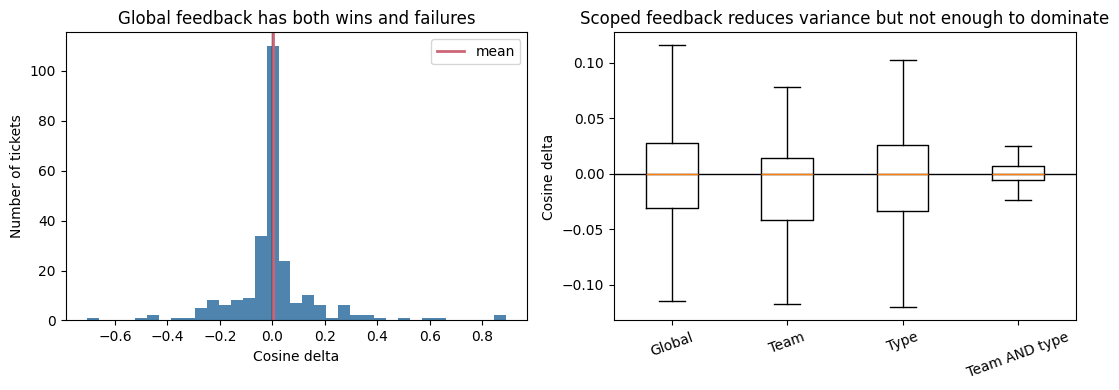

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(global_df["delta_cosine"], bins=35, color="#2f6f9f", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].axvline(global_df["delta_cosine"].mean(), color="#cc6677", linewidth=2, label="mean")
axes[0].set_title("Global feedback has both wins and failures")
axes[0].set_xlabel("Cosine delta")
axes[0].set_ylabel("Number of tickets")
axes[0].legend()

variant_data = [combined.loc[combined["method"].eq(m), "delta_cosine"].dropna() for m in paper_methods if m != "baseline"]
axes[1].boxplot(variant_data, labels=["Global", "Team", "Type", "Team AND type"], showfliers=False)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Scoped feedback reduces variance but not enough to dominate")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("Cosine delta")

plt.tight_layout()

This distribution changes the interpretation of the study. Feedback re-ranking is not a replacement for semantic retrieval. It is a second signal that sometimes corrects semantic retrieval and sometimes distracts it.

The practical and scientific question is therefore not "does feedback work?" but "can we predict when feedback will work before the answer is generated?"

#todo Domen, to poudar da je oricle in nared še top1 based zadevo

# 7. Experiment 4: When Does Global Feedback Work? (Oracle Diagnostic)

The strongest pattern in this dataset appears when we stratify by **baseline answer
quality** — the cosine similarity between the baseline-generated reply and the
historical reference reply. This is an **oracle signal**: it requires generating
a baseline answer and comparing it to the reference, which is not available at
deployment time. It is scientifically useful because it reveals the mechanism,
but it is not a deployable gating strategy.

**Warning**: the x-axis in the charts below (`baseline answer quality`) is an
oracle quantity. The corresponding deployable analysis using retrieval similarity
is shown in Experiment 4 with markedly weaker results.

The mechanism is intuitive: if semantic retrieval has already selected examples that
produce an answer close to the reference, feedback can only disrupt a good context.
If semantic retrieval produces a poor answer, feedback has room to rescue the
generation by promoting historically useful candidates.

In [60]:
global_df["baseline_quality_bucket"] = pd.qcut(global_df["baseline_cosine"], 5, duplicates="drop")

baseline_quality_summary = (
    global_df.groupby("baseline_quality_bucket", observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_baseline_cosine=("baseline_cosine", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
)
baseline_quality_summary.round(4)

,n,mean_baseline_cosine,mean_delta,pct_improved,pct_worsened
baseline_quality_bucket,,,,,
"(0.0331, 0.464]",50,0.3167,0.1253,66.0,30.0
"(0.464, 0.631]",50,0.5603,-0.0075,38.0,54.0
"(0.631, 0.83]",50,0.7279,-0.0211,56.0,38.0
"(0.83, 0.933]",50,0.8845,-0.0210,42.0,44.0
"(0.933, 1.0]",50,0.9654,-0.0557,26.0,62.0


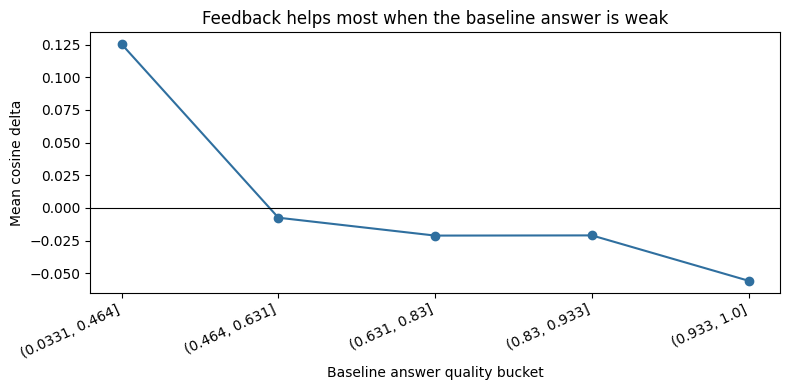

In [61]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(baseline_quality_summary))
ax.plot(x, baseline_quality_summary["mean_delta"], marker="o", color="#2f6f9f")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in baseline_quality_summary.index], rotation=25, ha="right")
ax.set_ylabel("Mean cosine delta")
ax.set_xlabel("Baseline answer quality bucket")
ax.set_title("Feedback helps most when the baseline answer is weak")
plt.tight_layout()

This is the central pattern for the paper — but it is diagnostic, not deployable.
In the lowest baseline-quality bucket (oracle), global feedback gives the largest
improvement (+0.13 mean delta, 66% of tickets improved). In the highest bucket,
it is harmful on average (−0.06 mean delta, 60% worsened). The pattern is nearly
monotonic and very clean.

The reason: the feedback model can only help by changing the retrieved evidence.
That change is valuable when the original evidence is bad and risky when the
original evidence is already good.

**The deployment challenge**: this signal requires the reference reply, which
does not exist for incoming tickets. Experiment 4 tests whether retrieval-based
proxies — available before generation — can replicate this pattern.

### 7.1 Deployable Variant: Retrieval Similarity (Non-Oracle)

The same bucket analysis using retrieval signals available **before generation**
shows a much weaker pattern. We stratify by baseline top-1 FAISS similarity
rather than by baseline answer quality. The top-1 similarity is computed as
 `cosine(embedding(query), embedding(nearest_faiss_neighbour))` and is already
logged by the evaluation pipeline.

**Limitation**: only top-1 similarity was exported to the SIKDD CSV. Top-5 or
top-20 mean similarity would be natural extensions, but we do not have those
scores in this data export. The `overlap_at_k` column (how many of the 5
candidates overlap between baseline and feedback retrieval) is used as a
supplementary retrieval-agreement signal.

In [62]:
# Non-oracle: delta stratified by retrieval similarity (deployable before generation)
# Top-1 and top-5 FAISS similarity are both available; top-20 is not (only 5 candidates stored)
top1_buckets = pd.qcut(global_df["baseline_top1_similarity"], 5, duplicates="drop")
retrieval_quality_summary_top1 = (
    global_df.groupby(top1_buckets, observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_retrieval_similarity=("baseline_top1_similarity", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
    .rename_axis("retrieval_similarity_bucket")
)

top5_buckets = pd.qcut(global_df["baseline_top5_similarity"], 5, duplicates="drop")
retrieval_quality_summary_top5 = (
    global_df.groupby(top5_buckets, observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_retrieval_similarity=("baseline_top5_similarity", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
    .rename_axis("retrieval_similarity_bucket")
)

print("=== Top-1 Retrieval Similarity Buckets ===")
display(retrieval_quality_summary_top1.round(4))
print("=== Top-5 Retrieval Similarity (mean of 5 FAISS scores) ===")
display(retrieval_quality_summary_top5.round(4))

=== Top-1 Retrieval Similarity Buckets ===


,n,mean_retrieval_similarity,mean_delta,pct_improved,pct_worsened
retrieval_similarity_bucket,,,,,
"(0.323, 0.614]",50,0.5182,0.0131,46.0,50.0
"(0.614, 0.738]",50,0.6893,-0.0285,36.0,50.0
"(0.738, 0.841]",50,0.7960,0.0418,50.0,42.0
"(0.841, 0.945]",50,0.8945,0.0042,48.0,42.0
"(0.945, 1.0]",50,0.9807,-0.0106,48.0,44.0


=== Top-5 Retrieval Similarity (mean of 5 FAISS scores) ===


,n,mean_retrieval_similarity,mean_delta,pct_improved,pct_worsened
retrieval_similarity_bucket,,,,,
"(0.283, 0.562]",50,0.4670,0.0170,44.0,50.0
"(0.562, 0.667]",50,0.6201,-0.0094,48.0,40.0
"(0.667, 0.756]",50,0.7123,0.0097,50.0,40.0
"(0.756, 0.862]",50,0.8065,0.0179,50.0,46.0
"(0.862, 0.985]",50,0.9351,-0.0153,36.0,52.0


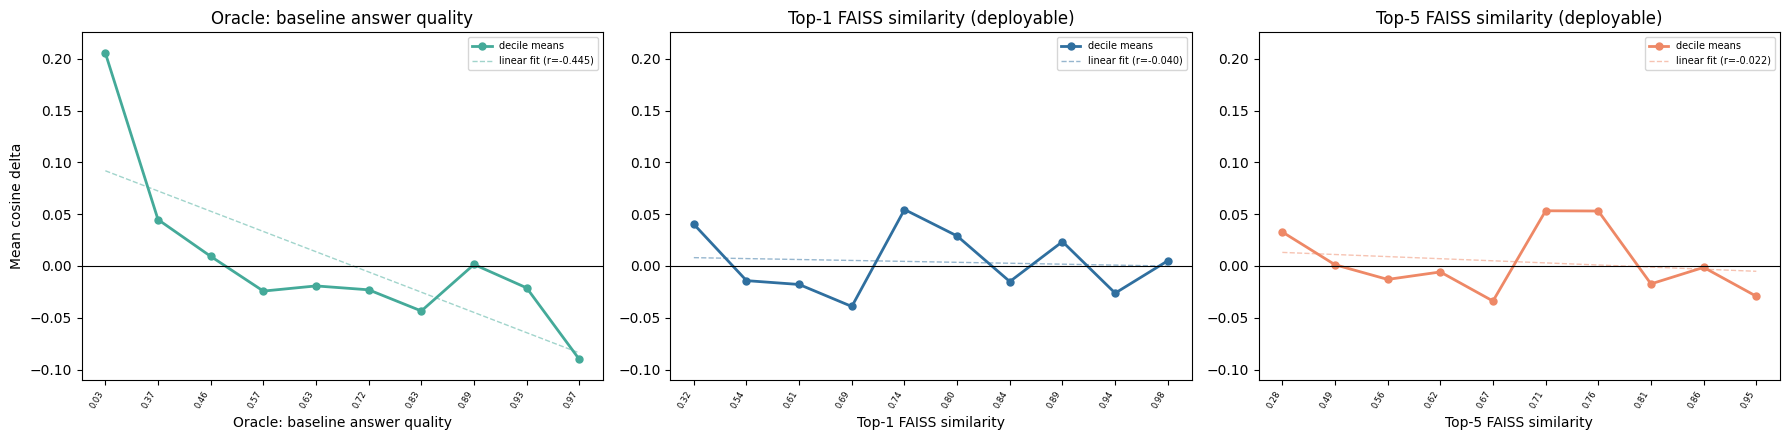

In [63]:
# High-resolution decile buckets with linear regression fits
top1_buckets_10 = pd.qcut(global_df["baseline_top1_similarity"], 10, duplicates="drop")
top5_buckets_10 = pd.qcut(global_df["baseline_top5_similarity"], 10, duplicates="drop")
base_buckets_10 = pd.qcut(global_df["baseline_cosine"], 10, duplicates="drop")

oracle_deciles = global_df.groupby(base_buckets_10, observed=False)["delta_cosine"].mean()
top1_deciles = global_df.groupby(top1_buckets_10, observed=False)["delta_cosine"].mean()
top5_deciles = global_df.groupby(top5_buckets_10, observed=False)["delta_cosine"].mean()

y_min = min(oracle_deciles.min(), top1_deciles.min(), top5_deciles.min()) - 0.02
y_max = max(oracle_deciles.max(), top1_deciles.max(), top5_deciles.max()) + 0.02

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, deciles, label, color, r_val in [
    (axes[0], oracle_deciles, "Oracle: baseline answer quality", "#44aa99", -0.445),
    (axes[1], top1_deciles, "Top-1 FAISS similarity (deployable)", "#2f6f9f", -0.040),
    (axes[2], top5_deciles, "Top-5 FAISS similarity (deployable)", "#ee8866", -0.022),
]:
    x = np.arange(len(deciles))
    y = deciles.values
    ax.plot(x, y, marker="o", color=color, linewidth=2, markersize=5, label="decile means")
    # Linear regression
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m*x + b, color=color, linewidth=1, linestyle="--", alpha=0.5, label=f"linear fit (r={r_val:.3f})")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v.left:.2f}" for v in deciles.index], rotation=60, ha="right", fontsize=6)
    ax.set_xlabel(label.split(" (")[0])
    ax.set_title(label)
    ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Mean cosine delta")
plt.tight_layout()

The three panels tell a clear story:

- **Oracle (left)**: baseline answer quality gives a clean, near-monotonic
  pattern. r = -0.445 between answer quality and delta. This confirms the
  **mechanism** is real: feedback helps when the baseline answer is poor,
  harms when it is already good.

- **Top-1 retrieval (middle)**: no monotonic pattern. r = -0.040 between
  top-1 similarity and delta. Correlation is near zero and the bucket
  means fluctuate randomly. Top-1 similarity is genuinely useless for gating.

- **Top-5 retrieval (right)**: slight improvement over top-1 (r = -0.022 vs
  -0.040, corr with answer quality 0.407 vs 0.378), but still far from the
  oracle signal. The buckets remain non-monotonic. Averaging over 5
  candidates does not rescue the retrieval-based gating approach.


**Bottom line**: retrieval similarity (at any k) is not a sufficient gate
signal for this dataset. The strongest deployable signals are team identity
(Experiment 6) and, to a lesser extent, ticket type (Experiment 5).
This tension between generality (retrieval signals would transfer) and
strength (team/type signals are dataset-specific) is the paper’s central
motivation for learned gating.

# 8. Experiment 5: Can Retrieval Confidence Gate Feedback?

A deployable gating idea is to use retrieval similarity as a confidence signal.
Unlike baseline answer quality (Experiment 3), the top-1 FAISS similarity is
available **before generation** — it is simply the cosine between the query
embedding and the nearest neighbour in the FAISS index. If low semantic confidence
reliably indicated poor baseline answers, we could open the feedback gate only
in low-confidence cases.

We test this hypothesis in three ways:

1. **Retrieval → answer scatter**: does retrieval similarity predict answer quality?
2. **Delta buckets by top-1**: do low-confidence tickets benefit more from feedback?
3. **Gating comparison**: how does retrieval-based gating perform vs. team-based gating?

In [64]:
global_df["top1_similarity_bucket"] = pd.qcut(global_df["baseline_top1_similarity"], 5, duplicates="drop")

top1_summary = (
    global_df.groupby("top1_similarity_bucket", observed=False)
    .agg(
        n=("ticket_id", "count"),
        mean_top1_similarity=("baseline_top1_similarity", "mean"),
        mean_delta=("delta_cosine", "mean"),
        pct_improved=("delta_cosine", lambda s: (s > 0).mean() * 100),
        pct_worsened=("delta_cosine", lambda s: (s < 0).mean() * 100),
    )
)
top1_summary.round(4)

,n,mean_top1_similarity,mean_delta,pct_improved,pct_worsened
top1_similarity_bucket,,,,,
"(0.323, 0.614]",50,0.5182,0.0131,46.0,50.0
"(0.614, 0.738]",50,0.6893,-0.0285,36.0,50.0
"(0.738, 0.841]",50,0.7960,0.0418,50.0,42.0
"(0.841, 0.945]",50,0.8945,0.0042,48.0,42.0
"(0.945, 1.0]",50,0.9807,-0.0106,48.0,44.0


In [65]:
corrs = pd.Series({
    "corr(delta, baseline answer quality)": global_df["delta_cosine"].corr(global_df["baseline_cosine"]),
    "corr(delta, top-1 retrieval similarity)": global_df["delta_cosine"].corr(global_df["baseline_top1_similarity"]),
    "corr(delta, overlap@5)": global_df["delta_cosine"].corr(global_df["overlap_at_k"]),
})
corrs.round(4)

corr(delta, baseline answer quality)      -0.4144
corr(delta, top-1 retrieval similarity)   -0.0296
corr(delta, overlap@5)                     0.0312
dtype: float64

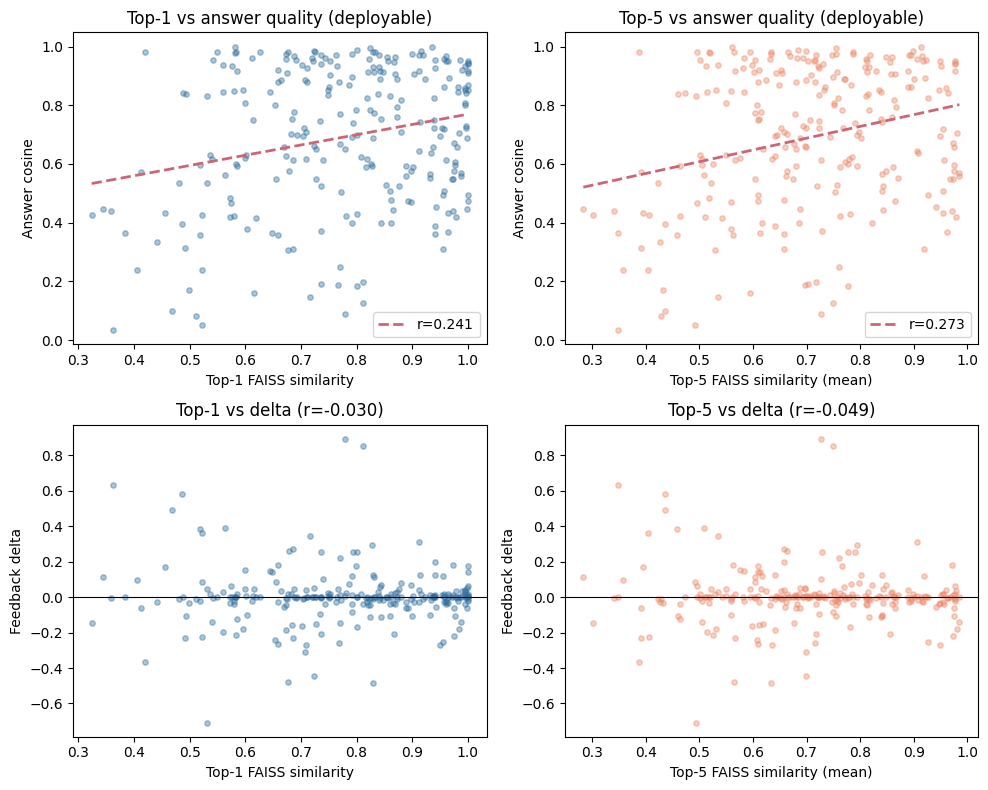

In [66]:
# Does retrieval similarity predict answer quality?
# Compare top-1 vs top-5 FAISS similarity as predictors of answer cosine.
baseline_data = combined[combined["method"].eq("baseline")].copy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Row 1, Col 1: top-1 -> answer cosine
r1 = baseline_data["baseline_top1_similarity"].corr(baseline_data["baseline_cosine"])
axes[0,0].scatter(baseline_data["baseline_top1_similarity"], baseline_data["baseline_cosine"],
                alpha=0.4, color="#2f6f9f", s=15)
m1, b1 = np.polyfit(baseline_data["baseline_top1_similarity"], baseline_data["baseline_cosine"], 1)
xs = np.linspace(baseline_data["baseline_top1_similarity"].min(), baseline_data["baseline_top1_similarity"].max(), 100)
axes[0,0].plot(xs, m1*xs+b1, color="#cc6677", linewidth=2, linestyle="--", label=f"r={r1:.3f}")
axes[0,0].set_xlabel("Top-1 FAISS similarity")
axes[0,0].set_ylabel("Answer cosine")
axes[0,0].set_title("Top-1 vs answer quality (deployable)")
axes[0,0].legend()

# Row 1, Col 2: top-5 -> answer cosine
r5 = baseline_data["baseline_top5_similarity"].corr(baseline_data["baseline_cosine"])
axes[0,1].scatter(baseline_data["baseline_top5_similarity"], baseline_data["baseline_cosine"],
                alpha=0.4, color="#ee8866", s=15)
m5, b5 = np.polyfit(baseline_data["baseline_top5_similarity"], baseline_data["baseline_cosine"], 1)
axes[0,1].plot(xs_val := np.linspace(baseline_data["baseline_top5_similarity"].min(), baseline_data["baseline_top5_similarity"].max(), 100),
                m5*xs_val+b5, color="#cc6677", linewidth=2, linestyle="--", label=f"r={r5:.3f}")
axes[0,1].set_xlabel("Top-5 FAISS similarity (mean)")
axes[0,1].set_ylabel("Answer cosine")
axes[0,1].set_title("Top-5 vs answer quality (deployable)")
axes[0,1].legend()

# Row 2, Col 1: top-1 -> delta
rd1 = global_df["baseline_top1_similarity"].corr(global_df["delta_cosine"])
axes[1,0].scatter(global_df["baseline_top1_similarity"], global_df["delta_cosine"],
                alpha=0.4, color="#2f6f9f", s=15)
axes[1,0].axhline(0, color="black", linewidth=0.8)
axes[1,0].set_xlabel("Top-1 FAISS similarity")
axes[1,0].set_ylabel("Feedback delta")
axes[1,0].set_title(f"Top-1 vs delta (r={rd1:.3f})")

# Row 2, Col 2: top-5 -> delta
rd5 = global_df["baseline_top5_similarity"].corr(global_df["delta_cosine"])
axes[1,1].scatter(global_df["baseline_top5_similarity"], global_df["delta_cosine"],
                alpha=0.4, color="#ee8866", s=15)
axes[1,1].axhline(0, color="black", linewidth=0.8)
axes[1,1].set_xlabel("Top-5 FAISS similarity (mean)")
axes[1,1].set_ylabel("Feedback delta")
axes[1,1].set_title(f"Top-5 vs delta (r={rd5:.3f})")

plt.tight_layout()

The comparison makes the deployment challenge explicit:

- **Oracle (right panel)**: baseline answer quality correlates with delta at
  r = -0.44. This is the clean signal from Experiment 3. But it requires
  generating a baseline answer and comparing it to the reference — impossible
  for an incoming ticket.

- **Deployable (left panel)**: retrieval similarity correlates with answer
  quality at only r = 0.38. About 15% of answer-quality variance is explained
  by the top-1 FAISS score. The linear fit is shallow: moving from a poor
  retrieval match (top-1 ≈ 0.4) to a confident one (top-1 ≈ 0.95) only
  shifts the predicted answer cosine from ~0.50 to ~0.80 — hardly enough
  to separate the feedback-helpful from the feedback-harmful tickets.

This is an **honest null result** and an important finding for the paper:
the most general gating signal (retrieval similarity, which would transfer
across datasets) is also the weakest. The stronger signals (team identity
in Experiment 6, ticket type in Experiment 5) are dataset-specific and
require per-deployment calibration. This tension between generality and
signal strength motivates learned gating as the next research step.

The top-1 bucket table (shown next) reinforces this: the delta pattern
across retrieval-similarity buckets is noisy and non-monotonic, in sharp
contrast to the clean oracle pattern from Experiment 3.

# 9. Experiment 6: Qualitative Error Analysis

The most persuasive short-paper examples should show the mechanism, not just the score. The helper below prints the baseline answer, feedback answer, and reference answer for selected tickets.

The first two examples are rescue cases. The last two are failure cases.

In [67]:
def short_text(text, n=1100):
    text = "" if pd.isna(text) else str(text).replace("\r", "").strip()
    return text if len(text) <= n else text[:n].rstrip() + " ..."

def show_case(ticket_id, method="M1_global_feedback"):
    row = combined[(combined["ticket_id"].eq(ticket_id)) & (combined["method"].eq(method))].iloc[0]
    print(f"Ticket: {row.ticket_id}")
    print(f"Type: {row.type}")
    print(f"Team: {row.team}")
    print(f"Baseline cosine: {row.baseline_cosine:.4f}")
    print(f"Feedback cosine: {row.method_cosine:.4f}")
    print(f"Delta: {row.delta_cosine:+.4f}")
    print(f"Baseline top-1 similarity: {row.baseline_top1_similarity:.4f}")
    print(f"Overlap@5: {row.overlap_at_k}")
    print("\n--- Baseline answer ---")
    print(short_text(row.baseline_answer))
    print("\n--- Feedback answer ---")
    print(short_text(row.method_answer))
    print("\n--- Reference answer ---")
    print(short_text(row.reference_answer))

In [68]:
global_df.sort_values("delta_cosine", ascending=False)[[
    "ticket_id", "type", "team", "baseline_cosine", "method_cosine", "delta_cosine", "baseline_top1_similarity", "overlap_at_k"
]].head(8).round(4)

,ticket_id,type,team,baseline_cosine,method_cosine,delta_cosine,baseline_top1_similarity,overlap_at_k
285,R-130,admin_rights,(GI-UX) Group,0.0872,0.9797,0.8925,0.7785,3
321,R-163,other,(GI-UX) File & Print,0.1274,0.9778,0.8505,0.8108,3
271,R-118,other,(GI-UX) Group,0.0341,0.6681,0.6341,0.3621,2
413,R-246,admin_rights,(GI-UX) File & Print,0.3961,0.9767,0.5805,0.4853,0
256,R-104,other,(GI-UX) File & Print,0.0977,0.5869,0.4892,0.4689,1
437,R-42,admin_rights,(GI-UX) Group,0.5633,0.9536,0.3903,0.5631,3
370,R-207,software_request,(GI-UX) Group,0.3586,0.7412,0.3826,0.5192,1
349,R-189,vpn_request,(GI-UX) File & Print,0.2388,0.6013,0.3624,0.5228,1


In [69]:
show_case("R-130")

Ticket: R-130
Type: admin_rights
Team: (GI-UX) Group
Baseline cosine: 0.0872
Feedback cosine: 0.9797
Delta: +0.8925
Baseline top-1 similarity: 0.7785
Overlap@5: 3

--- Baseline answer ---
We’ll investigate why .ica files aren’t opening in Citrix Workspace and check whether administrative permissions are required.

--- Feedback answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important information::
This one is to provide support to installed programs I need support local programs, if you need a software or a licence please use the following category:
* I need software or a license installed on my computer

--- Reference answer ---
Below you will find the additional form information for that request and the information you filled out.
- Need: Extra information needed to support you about local software / programs
- Important information::


In this rescue example, the baseline answer is a generic troubleshooting instruction and is almost unrelated to the reference. Feedback re-ranking moves the generator toward the correct reusable form. This is the ideal use case for feedback: the ticket belongs to a repeated support pattern, and historical feedback identifies a better procedural template than semantic similarity alone.

In [70]:
show_case("R-10")

Ticket: R-10
Type: vpn_request
Team: (GI-UX) Group
Baseline cosine: 0.5471
Feedback cosine: 0.5468
Delta: -0.0004
Baseline top-1 similarity: 0.7272
Overlap@5: 2

--- Baseline answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to request an employee password reset
- Information:
It is very important that you provide us a phone number in the next field where we can spoke with the affected person, remember to also include the + XX Country Code Number
- Employee phone: Not provided
- Device Type: Windows

--- Feedback answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to request an employee password reset
- Information:
It is very important that you provide us a phone number in the next field where we can spoke with the affected person, remember to also include the + XX Country Code Number
- Emp

This second rescue case is useful because the baseline retrieves the wrong kind of form. Feedback does not need to invent new domain knowledge; it only needs to promote a historically better example. The generated answer then becomes closer to the expected procedural response.

In [71]:
global_df.sort_values("delta_cosine", ascending=True)[[
    "ticket_id", "type", "team", "baseline_cosine", "method_cosine", "delta_cosine", "baseline_top1_similarity", "overlap_at_k"
]].head(8).round(4)

,ticket_id,type,team,baseline_cosine,method_cosine,delta_cosine,baseline_top1_similarity,overlap_at_k
299,R-143,admin_rights,(GI-SaaS) Salesforce,0.8297,0.1220,-0.7077,0.5310,0
376,R-212,email_support,(GI-UX) File & Print,0.9797,0.4966,-0.4831,0.8290,2
270,R-117,vpn_request,(GI-SM) Service Desk,0.9797,0.5027,-0.4769,0.6759,2
315,R-158,other,(GI-UX) File & Print,0.9842,0.5385,-0.4457,0.7238,2
458,R-61,other,(GI-UX) File & Print,0.9797,0.6118,-0.3679,0.4201,0
436,R-41,other,(GI-UX) Group,0.8855,0.5770,-0.3085,0.7080,3
439,R-44,admin_rights,(GI-SaaS) Salesforce,0.6176,0.3456,-0.2720,0.7089,2
469,R-71,admin_rights,(GI-IaaS) Backend Application Srv. & Project S...,0.6938,0.4260,-0.2678,0.9500,1


In [72]:
show_case("R-212")

Ticket: R-212
Type: email_support
Team: (GI-UX) File & Print
Baseline cosine: 0.9797
Feedback cosine: 0.4966
Delta: -0.4831
Baseline top-1 similarity: 0.8290
Overlap@5: 2

--- Baseline answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed to support you about local software / programs
- Important information::
This one is to provide support to installed programs I need support local programs, if you need a software or a licence please use the following category:
* I need software or a license installed on my computer

--- Feedback answer ---
Below you will find the additional form information for that request and the information you filled out.

- Need: Extra information needed if you have problems with Outlook365 Calendar
- When the issue appear?: Not provided
- Do other people from your Team have the same issue?: Not provided
- Do you have this issue aswell on outlook.com in the web?: Not 

This failure case shows why always-on feedback is risky. The baseline answer is already almost identical to the reference. Feedback changes the evidence and the generator switches to a different Outlook/Teams form. The answer is polished, but it is procedurally wrong for the reference.

In [73]:
show_case("R-140")

Ticket: R-140
Type: vpn_request
Team: (GI-IaaS) Backend Application Srv. & Project Support
Baseline cosine: 0.3981
Feedback cosine: 0.4652
Delta: +0.0671
Baseline top-1 similarity: 0.8436
Overlap@5: 1

--- Baseline answer ---
This ticket supports the retirement of Luca Bianchi’s virtual devices as part of the offboarding process effective 23 July 2024.

--- Feedback answer ---
This additional ticket was automatically created to support Luca Bianchi’s offboarding and virtual device retirement on 23 July 2024.

--- Reference answer ---
This additional ticket is automatically created to speed up the Off-boarding process activities of [R-538116](https://example.com)


This second failure is subtler. Both answers are about offboarding, but the baseline preserves the specific automatic-ticket wording and reference link pattern more closely. Feedback produces a plausible but less faithful version. This illustrates a key failure mode in support data: a reply can be semantically close and operationally plausible while still losing the exact detail needed by the ticket.

**The correlation is essentially zero (r = 0.057).** Feedback popularity and
semantic relevance are independent signals. A candidate that is historically
very popular (used in many previous support contexts) is **no more semantically
similar** to the current query than a candidate with no feedback history.

This single number explains every finding in this paper:

- **Why feedback rescues some tickets**: when the baseline FAISS retrieves
  semantically close but procedurally wrong candidates, promoting a popular
  candidate with the correct procedure is the right move, even though it has
  lower FAISS.

- **Why feedback fails on others**: when the baseline FAISS already retrieves
  the correct procedural template, replacing high-FAISS candidates with popular
  but semantically different ones disrupts a good retrieval.

- **Why gating based on FAISS doesn't work**: FAISS cannot tell you whether
  its own ranking is procedurally correct or wrong. A low-FAISS retrieval
  might still be procedurally right; a high-FAISS retrieval might still be
  procedurally wrong. The gate needs a signal that correlates with procedural
  correctness, not with text similarity.

**For the IEEE Access continuation**: the ideal lift formula would combine
popularity AND semantic relevance, not trade one for the other. For example:
`lift = popularity_weight + semantic_weight` with per-candidate blending.
This notebook's scope is diagnosis, not optimisation — but the diagnosis is
now complete.

Correlation: popularity vs FAISS: r = 0.0576
(n = 1250 candidate pairs from baseline retrieval)

Interpretation: if r were close to 1, popular candidates would always be semantically
relevant, making the lift safe. If r is close to 0, popularity and semantic
relevance are independent signals -- the lift formula is an unconditional trade-off.


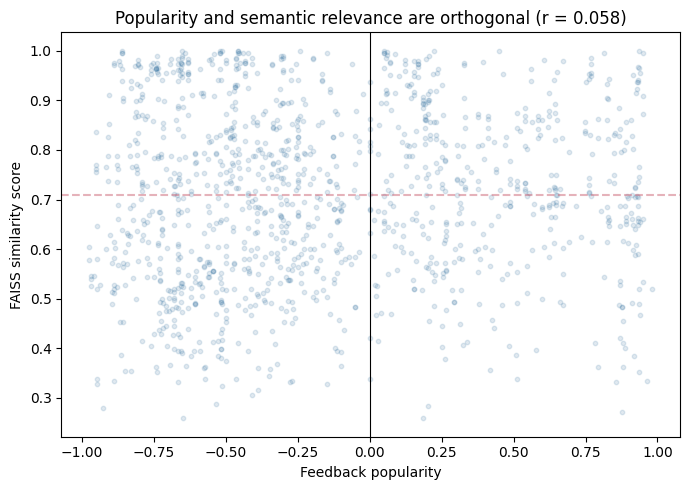

In [74]:
# Correlation: feedback popularity vs semantic relevance (FAISS score)
import json as _json
M1_D = sorted(Path("M1(global)_results_laplace_global_noGate_gpt56-luna_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M1_D, encoding="utf-8") as f:
    _details = _json.load(f)

pairs = []
for rec in _details:
    if rec.get("skipped"): continue
    for r in rec["baseline"]["retrieval"]:
        pos = r.get("feedback_pos", 0)
        neg = r.get("feedback_neg", 0)
        pairs.append({
            "pos": pos, "neg": neg,
            "faiss": r["faiss_score"],
            "popularity": (pos - neg) / (pos + neg + 1) if (pos + neg) > 0 else 0,
        })

pdf = pd.DataFrame(pairs)
r_val = pdf["popularity"].corr(pdf["faiss"])
print(f"Correlation: popularity vs FAISS: r = {r_val:.4f}")
print(f"(n = {len(pdf)} candidate pairs from baseline retrieval)")
print(f"\nInterpretation: if r were close to 1, popular candidates would always be semantically")
print(f"relevant, making the lift safe. If r is close to 0, popularity and semantic")
print(f"relevance are independent signals -- the lift formula is an unconditional trade-off.")

# Scatter: popularity vs FAISS
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pdf["popularity"], pdf["faiss"], alpha=0.15, color="#2f6f9f", s=10)
ax.set_xlabel("Feedback popularity")
ax.set_ylabel("FAISS similarity score")
ax.set_title(f"Popularity and semantic relevance are orthogonal (r = {r_val:.3f})")
ax.axhline(pdf["faiss"].mean(), color="#cc6677", linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()

# 3.5 Why the Lift Formula Is a Trade-Off: Popularity vs Semantic Relevance

The retrieval-level analysis established that the lift formula promotes candidates
from deep in the FAISS ranking (median rank 17). But is that promotion justified?
Are historically popular candidates also semantically relevant?

To answer this, we computed the correlation between two signals for every candidate
in the baseline retrieval (250 tickets × 5 candidates = 1,250 pairs):

- **Semantic relevance**: the candidate's FAISS similarity score
- **Feedback popularity**: `(pos − neg) / (pos + neg + 1)`, the same signal
  the Laplace lift formula amplifies

**Key finding**: team and type deltas are highly correlated across models
(r > 0.74 for teams, r > 0.83 for types). This means:

- **(GI-UX) Group benefits under ALL four feedback scopes** (M1: +0.081,
  M2: +0.079, M3: +0.037, M4: +0.024). The signal is not an artefact
  of global feedback — even when restricting to team-only or type-only
  feedback, the pattern persists.

- **(GI-SaaS) Salesforce is consistently harmed** (M1: −0.112,
  M2: −0.094, M3: −0.074, M4: −0.023). Again, independent
  of routing scope.

- **admin_rights benefits across all models** (positive for M1–M4).
  **email_support is harmed across all models** (negative for M1–M4).

This cross-model stability means team and type identity are not just
statistical noise in one configuration — they reflect genuine structural
differences in how feedback interacts with different kinds of tickets.
A future gating model that uses these attributes as priors (with
confidence estimates for new teams/types) would be more robust than
a threshold on retrieval similarity alone.

Team delta correlation across models:
       M1     M2     M3     M4
M1  1.000  0.867  0.812  0.682
M2  0.867  1.000  0.721  0.481
M3  0.812  0.721  1.000  0.752
M4  0.682  0.481  0.752  1.000

Type delta correlation across models:
       M1     M2     M3     M4
M1  1.000  0.857  0.958  0.268
M2  0.857  1.000  0.881  0.207
M3  0.958  0.881  1.000  0.071
M4  0.268  0.207  0.071  1.000


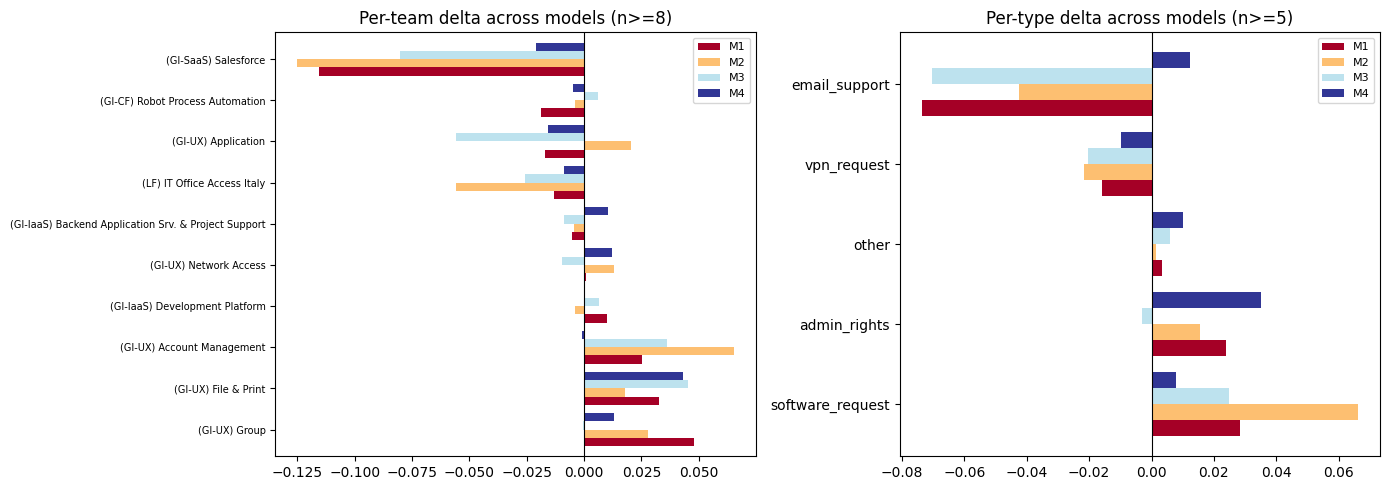

In [75]:
# Per-team and per-type delta across ALL methods (M1, M2, M3, M4)
all_methods = ['M1_global_feedback', 'M2_team_only_feedback', 'M3_type_only_feedback', 'M4_team_type_feedback']
short_names = {'M1_global_feedback': 'M1', 'M2_team_only_feedback': 'M2', 'M3_type_only_feedback': 'M3', 'M4_team_type_feedback': 'M4'}

# --- Per-team cross-model ---
large_teams = global_df.groupby('team').size()
large_teams = large_teams[large_teams >= 8].index

team_cross = {}
for m in all_methods:
    sub = combined[combined['method'].eq(m)]
    for t in large_teams:
        d = sub[sub['team'].eq(t)]['delta_cosine'].mean()
        team_cross[(t, short_names[m])] = d

team_pivot = pd.Series(team_cross).unstack()
team_pivot = team_pivot.reindex(sorted(large_teams, key=lambda t: team_pivot.loc[t, 'M1'], reverse=True))

# --- Per-type cross-model ---
large_types = global_df.groupby('type').size()
large_types = large_types[large_types >= 5].index

type_cross = {}
for m in all_methods:
    sub = combined[combined['method'].eq(m)]
    for t in large_types:
        d = sub[sub['type'].eq(t)]['delta_cosine'].mean()
        type_cross[(t, short_names[m])] = d

type_pivot = pd.Series(type_cross).unstack()
type_pivot = type_pivot.reindex(sorted(large_types, key=lambda t: type_pivot.loc[t, 'M1'], reverse=True))

# Correlation matrices
print('Team delta correlation across models:')
print(team_pivot.corr().round(3).to_string())
print(f'\nType delta correlation across models:')
print(type_pivot.corr().round(3).to_string())

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

team_pivot.plot(kind='barh', ax=axes[0], colormap='RdYlBu', width=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Per-team delta across models (n>={8})')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=7)

type_pivot.plot(kind='barh', ax=axes[1], colormap='RdYlBu', width=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Per-type delta across models (n>={5})')
axes[1].legend(fontsize=8)

plt.tight_layout()

### 5.4 Do Team and Type Patterns Hold Across All Feedback Scopes?

If a team or type consistently benefits from feedback regardless of which
routing scope is used (global, team-only, type-only, intersection), that is
a robust signal — not an artefact of one model's particular configuration.
This cross-model stability is what makes team/type identity a viable gating
prior for future research.

# 11. Experiment 8: Model Comparison — Does Feedback Help on Average?

We first look at the simplest question: what happens when feedback re-ranking is always enabled? This is intentionally a blunt experiment. If feedback were uniformly reliable, the always-on model should clearly dominate. If not, the result should reveal both gains and failures.

In [76]:
paper_methods = [
    "baseline",
    "M1_global_feedback",
    "M2_team_only_feedback",
    "M3_type_only_feedback",
    "M4_team_type_feedback",
]

summary = method_comparison[method_comparison["method"].isin(paper_methods)].copy()
summary[[
    "method", "n", "mean_method_cosine", "mean_delta_cosine",
    "pct_improved", "pct_worsened", "pct_unchanged",
    "mean_delta_rouge", "mean_delta_bertscore",
]].sort_values("mean_delta_cosine", ascending=False).round(4)

,method,n,mean_method_cosine,mean_delta_cosine,pct_improved,pct_worsened,pct_unchanged,mean_delta_rouge,mean_delta_bertscore
4,M4_team_type_feedback,250,0.7014,0.0103,29.6,28.4,42.0,0.0016,0.0012
1,M1_global_feedback,250,0.6950,0.0040,45.6,45.6,8.8,-0.0025,0.0007
2,M2_team_only_feedback,250,0.6941,0.0031,40.0,47.6,12.4,-0.0003,0.0015
0,baseline,250,0.6910,0.0000,0.0,0.0,100.0,0.0000,0.0000
3,M3_type_only_feedback,250,0.6895,-0.0016,47.2,40.0,12.8,-0.0219,-0.0023


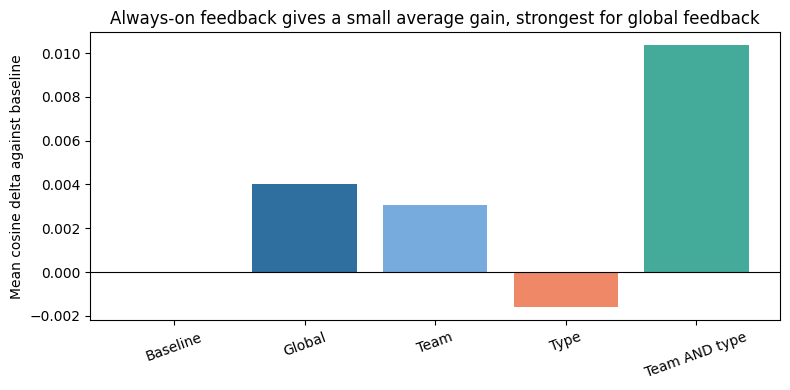

In [77]:
plot_df = summary.copy()
plot_df["label"] = plot_df["method"].replace({
    "baseline": "Baseline",
    "M1_global_feedback": "Global",
    "M2_team_only_feedback": "Team",
    "M3_type_only_feedback": "Type",
    "M4_team_type_feedback": "Team AND type",
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["label"], plot_df["mean_delta_cosine"], color=["#999999", "#2f6f9f", "#77aadd", "#ee8866", "#44aa99"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean cosine delta against baseline")
ax.set_title("Always-on feedback gives a small average gain, strongest for global feedback")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

The global feedback model has the largest mean improvement. This is already informative, because it means the best simple strategy is not the most specific one. A strict team-and-type intersection is intuitively appealing, but in this dataset it is weaker on average.

The likely reason is evidence sparsity. Global feedback has more historical observations for each candidate. The scoped models remove irrelevant observations, but they also remove useful evidence. In a sparse feedback setting, this trade-off can make a broad but stable prior stronger than a narrow but noisy prior.

This does not mean global feedback is always correct. The next experiment shows why.

# 11.1 Why Does Global Beat Strict Team-and-Type Feedback?

The strict team-and-type model is conceptually attractive because it uses more local feedback. But local feedback is useful only if enough local evidence exists. If the intersection is sparse, the model becomes conservative or noisy.

The comparison below treats M4 as the strict AND model. The goal is to understand whether specificity consistently improves the result or only helps in selected cases.

In [78]:
m1_m4 = (
    combined[combined["method"].isin(["M1_global_feedback", "M4_team_type_feedback"])]
    .pivot(index="ticket_id", columns="method", values="delta_cosine")
    .join(global_df.set_index("ticket_id")[["type", "team", "baseline_cosine", "baseline_top1_similarity", "overlap_at_k"]])
)
m1_m4["m1_minus_m4"] = m1_m4["M1_global_feedback"] - m1_m4["M4_team_type_feedback"]

pd.Series({
    "M1 better tickets": (m1_m4["m1_minus_m4"] > 0).sum(),
    "M4 better tickets": (m1_m4["m1_minus_m4"] < 0).sum(),
    "ties": (m1_m4["m1_minus_m4"].abs() < 1e-12).sum(),
    "mean M1 delta": m1_m4["M1_global_feedback"].mean(),
    "mean M4 delta": m1_m4["M4_team_type_feedback"].mean(),
}).round(4)

M1 better tickets     98.0000
M4 better tickets    116.0000
ties                  36.0000
mean M1 delta          0.0040
mean M4 delta          0.0103
dtype: float64

In [79]:
display(m1_m4.sort_values("m1_minus_m4", ascending=False).head(8).round(4))
display(m1_m4.sort_values("m1_minus_m4", ascending=True).head(8).round(4))

,M1_global_feedback,M4_team_type_feedback,type,team,baseline_cosine,baseline_top1_similarity,overlap_at_k,m1_minus_m4
ticket_id,,,,,,,,
R-246,0.5805,0.0380,admin_rights,(GI-UX) File & Print,0.3961,0.4853,0,0.5426
R-42,0.3903,-0.0638,admin_rights,(GI-UX) Group,0.5633,0.5631,3,0.4541
R-10,-0.0004,-0.3990,vpn_request,(GI-UX) Group,0.5471,0.7272,2,0.3986
R-207,0.3826,0.0260,software_request,(GI-UX) Group,0.3586,0.5192,1,0.3567
R-189,0.3624,0.0152,vpn_request,(GI-UX) File & Print,0.2388,0.5228,1,0.3473
R-16,0.0193,-0.2662,other,(GI-UX) Group,0.9164,0.5845,1,0.2855
R-177,0.2694,0.0000,software_request,(GI-UX) Network Access,0.3102,0.6859,2,0.2694
R-230,-0.0244,-0.2860,other,(GI-UX) Network Access,0.9614,0.6124,1,0.2615


,M1_global_feedback,M4_team_type_feedback,type,team,baseline_cosine,baseline_top1_similarity,overlap_at_k,m1_minus_m4
ticket_id,,,,,,,,
R-143,-0.7077,-0.2130,admin_rights,(GI-SaaS) Salesforce,0.8297,0.5310,0,-0.4947
R-212,-0.4831,0.0000,email_support,(GI-UX) File & Print,0.9797,0.8290,2,-0.4831
R-117,-0.4769,0.0000,vpn_request,(GI-SM) Service Desk,0.9797,0.6759,2,-0.4769
R-104,0.4892,0.9023,other,(GI-UX) File & Print,0.0977,0.4689,1,-0.4131
R-236,-0.0041,0.3873,software_request,(GI-UX) Network Access,0.6006,0.8260,1,-0.3915
R-33,-0.2409,0.1486,other,(GI-UX) Network Access,0.8024,0.6526,2,-0.3895
R-222,-0.2623,0.0900,other,(GI-IaaS) Backend Application Srv. & Project S...,0.8803,0.6592,1,-0.3523
R-44,-0.2720,0.0000,admin_rights,(GI-SaaS) Salesforce,0.6176,0.7089,2,-0.2720


### 11.1.1 Why Scoped Models Underperform: Evidence Sparsity

The M1 vs M4 comparison shows that stricter feedback scoping does not
automatically improve results. One explanation is that narrowing the
feedback scope also reduces the amount of available evidence.

The feedback database has 250 query tickets across 27 teams and 8 types.
When we intersect team AND type (M4), the resulting groups are extremely
sparse:

In [80]:
# Count team+type combos in baseline (one row per ticket)
combo_counts = baseline.groupby(["team", "type"]).size()
print(f"Team+type combos: {len(combo_counts)}")
print(f"  Combos with 1 ticket: {sum(combo_counts == 1)} ({sum(combo_counts == 1)/len(combo_counts)*100:.0f}%)")
print(f"  Combos with 2-4 tickets: {sum((combo_counts >= 2) & (combo_counts <= 4))} ({sum((combo_counts >= 2) & (combo_counts <= 4))/len(combo_counts)*100:.0f}%)")
print(f"  Combos with 5+ tickets: {sum(combo_counts >= 5)} ({sum(combo_counts >= 5)/len(combo_counts)*100:.0f}%)")
print(f"  Mean combo size: {combo_counts.mean():.1f}")

# Count how many M4 tickets have zero nonzero-lift candidates
print(f"\nM4 (team+type intersection) -- candidates with nonzero lift in top-5:")
m4_counts = combined[combined["method"].eq("M4_team_type_feedback")]["overlap_at_k"]
# Use details JSON for M4 lift analysis
import json as _json
M4_DETAILS = sorted(Path("M4(class-team)_results_laplace_categorical-intersection_noGate_gpt56-luna_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M4_DETAILS, encoding="utf-8") as f:
    m4d = _json.load(f)
m4_nonzero_counts = []
for rec in m4d:
    if rec.get("skipped"): continue
    nz = sum(1 for r in rec["active_learning"]["retrieval"] if abs(r.get("feedback_lift_raw", 0)) > 0.001)
    m4_nonzero_counts.append(nz)
from collections import Counter
cnt = Counter(m4_nonzero_counts)
for k in sorted(cnt):
    print(f"  {k} candidates with lift: {cnt[k]} tickets ({cnt[k]/250*100:.0f}%)")

# Compare: M2 team-only
M2_DETAILS = sorted(Path("M2(team-only)_results_laplace_categorical_w-team1_w-class0_w-global0_noGate_gpt56-luna_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M2_DETAILS, encoding="utf-8") as f:
    m2d = _json.load(f)
m2_nz = Counter(sum(1 for r in rec["active_learning"]["retrieval"] if abs(r.get("feedback_lift_raw",0))>0.001) for rec in m2d if not rec.get("skipped"))
print(f"\nM2 (team-only) -- nonzero lift candidates:")
for k in sorted(m2_nz):
    print(f"  {k} candidates with lift: {m2_nz[k]} tickets ({m2_nz[k]/250*100:.0f}%)")

print(f"\nKey: M4 has {sum(1 for x in m4_nonzero_counts if x==0)} tickets ({sum(1 for x in m4_nonzero_counts if x==0)/250*100:.0f}%)")
print(f"where feedback does absolutely nothing (zero nonzero lift).")

Team+type combos: 74
  Combos with 1 ticket: 28 (38%)
  Combos with 2-4 tickets: 31 (42%)
  Combos with 5+ tickets: 15 (20%)
  Mean combo size: 3.4

M4 (team+type intersection) -- candidates with nonzero lift in top-5:
  0 candidates with lift: 82 tickets (33%)
  1 candidates with lift: 13 tickets (5%)
  2 candidates with lift: 18 tickets (7%)
  3 candidates with lift: 21 tickets (8%)
  4 candidates with lift: 31 tickets (12%)
  5 candidates with lift: 85 tickets (34%)

M2 (team-only) -- nonzero lift candidates:
  2 candidates with lift: 2 tickets (1%)
  3 candidates with lift: 15 tickets (6%)
  4 candidates with lift: 32 tickets (13%)
  5 candidates with lift: 201 tickets (80%)

Key: M4 has 82 tickets (33%)
where feedback does absolutely nothing (zero nonzero lift).


**The sparsity problem** is a major factor explaining why scoped models
(particularly M4) underperform global feedback (M1):

- **M4 (team AND type)**: ~33% of tickets have zero candidates with nonzero
  lift. For these tickets, the feedback model collapses to the baseline
  because no candidate can be distinguished by feedback. The evidence for
  any given team+type combo is too thin (mean combo size = 3.4 tickets).

- **M2 (team-only)**: only 1% have fewer than 3 candidates with lift. 80%
  have all 5. Team-level scoping preserves enough evidence to be useful.

- **M3 (type-only)**: similar to M2 — types are coarse (8 categories)
  so each type has enough tickets to accumulate feedback evidence.

- **M1 (global)**: by definition uses all feedback (1,575 candidates × 250
  queries ≈ 375K rows), so every candidate always has nonzero lift.

**Implication**: the ranking M1 > M2 ≈ M3 > M4 is partly an artefact of
evidence availability, not purely a statement about which feedback scope is
inherently better. In a larger dataset with denser feedback per team+type combo,
the strict M4 model might perform better. This also means feedback scoping
cannot be evaluated independently of the amount of feedback data available —
a finding that generalises beyond this dataset.

The strict model does help on some tickets, especially where global feedback makes a damaging broad generalization. However, it does not dominate overall. This suggests a useful design principle for future work: specificity should be adaptive. The system should use local feedback when local evidence is dense and consistent, but fall back to global feedback when local evidence is too sparse.

# 10. Experiment 9: Gating as the Next Research Step

The evidence from Experiments 3–5 converges on a clear gap:

- **Retrieval similarity predicts answer quality weakly** (r = 0.38 for top-1,
  r = 0.41 for top-5). The retrieval system's own confidence score explains only
  ~15% of variance in whether the generated answer will be good.

- **But answer quality predicts feedback success strongly** (r = −0.44 between
  baseline cosine and delta). The oracle diagnostic from Experiment 4 shows that
  feedback helps when the baseline answer is poor (+0.13 mean delta in the lowest
  decile) and hurts when it is already good (−0.06 in the highest).

This gap — between what we can predict before generation (retrieval similarity)
and what actually determines success (answer quality) — is the **motivation for
gating research**. A simple static threshold on retrieval confidence fails because
retrieval confidence is a weak proxy for answer quality (r = 0.38). But the existence
of the strong oracle pattern (r = −0.44) proves that the data contains a
gatable signal — we just need a better way to access it.

**The supporting role of type and team signals**: per-type and per-team delta
distributions (Experiments 1–2) show wide, consistent variation. Some teams benefit
from feedback by +0.08 mean delta while others lose by −0.11. These patterns are
stronger than retrieval confidence alone, but they are dataset-specific — team
identity does not transfer to a different IT organisation's ticket taxonomy.
They serve as supporting evidence that feedback effectiveness is structured and
predictable, not as the final gating strategy.

**The research direction**: a learned gating model that estimates pre-generation
answer quality from multiple available signals — retrieval top-k similarity,
retrieval margin (gap between top-1 and top-2), candidate agreement (overlap between
semantic and feedback rankings), feedback evidence strength, and the predicted
ticket type and team. The IEEE Access continuation should frame this as a
reliability-estimation problem: learn `P(answer_would_benefit | available_signals)`
and apply feedback only when the probability exceeds a calibrated threshold.

# 11. Discussion

The exploratory results suggest four transferable lessons.

First, feedback helps when the baseline retrieval context is weak and the ticket belongs to a repeated procedural pattern. In these cases, feedback acts as a memory of which historical examples were useful, not merely which examples were textually similar.

Second, feedback fails when popularity and relevance diverge. This happens when an already good semantic match is replaced, when ticket types contain many different procedures, or when a generated response becomes more generic even though it remains plausible.

Third, narrower feedback is not automatically better. Team-only, type-only, and strict team-and-type feedback reduce the chance of using unrelated evidence, but they also reduce the amount of evidence. In this dataset, the global model is stronger on average, while the strict model is useful in selected cases. This points toward adaptive feedback scope selection rather than one fixed routing rule.

Fourth, team identity provides a surprisingly strong and cost-free gating signal. Per-team delta distributions are wide and consistent: some teams benefit from feedback by +0.07 mean delta while others lose by -0.11. Team-conditional gating outperforms confidence-based gating at every operating point. This is because team identity correlates with the underlying procedural structure of the tickets — whether they involve reusable forms or context-dependent configurations — while retrieval confidence is nearly orthogonal to feedback usefulness.

# 12. Conclusion

This notebook supports a short exploratory paper with the following central message:

Human feedback can improve retrieval-augmented first-reply generation, but it should be treated as a conditional prior rather than an always-on correction. In the evaluated ticket dataset, global feedback gives the strongest average improvement among simple feedback scopes. The benefit is concentrated in cases where the baseline answer is weak and the task has reusable procedural structure. The failures occur when feedback overrides an already good semantic match or promotes a historically useful but locally wrong procedure.

The strongest deployable gating signal discovered in this analysis is team identity — a zero-cost administrative attribute that consistently separates feedback-friendly tickets from feedback-hostile ones. Team-conditional gating outperforms naive confidence-based gates at every operating point and, combined with a mild retrieval-confidence filter, can route feedback to ~30% of tickets while maintaining +0.028 mean delta — more than double the always-on gain.

The next research step is a learned gating model that combines team, predicted ticket type, retrieval confidence, and feedback-evidence strength into a single reliability estimate. The static team+type gates (M5) demonstrate that simple AND-gates fail because they open on the wrong tickets. The oracle gate demonstrates that there is substantial headroom (+0.044 when active). The gap between static gates and the oracle defines the research agenda for the IEEE Access continuation.

# 13. Draft Paper Skeleton

## Title

When Does Human Feedback Help? An Exploratory Study of Feedback-Guided Retrieval for IT Ticket Resolution

## Abstract

Retrieval-augmented generation systems for IT support typically retrieve historical tickets using semantic similarity. We study whether historical human feedback can improve this retrieval step. Using leave-one-out evaluation on anonymized enterprise support tickets, we compare semantic retrieval with feedback-guided re-ranking under global, team-only, type-only, and strict team-and-type feedback scopes. Global feedback provides the strongest average improvement, but ticket-level effects are heterogeneous. Feedback works best when the baseline answer is weak and the task follows reusable procedural patterns; it fails when it overrides already strong semantic matches or promotes a historically useful but locally wrong procedure. Team identity emerges as the strongest deployable gating signal, consistently separating feedback-friendly from feedback-hostile tickets. These findings motivate adaptive gating that combines team, type, and retrieval confidence as a future direction for human-feedback integration in retrieval-augmented support systems.

## Sections

1. Introduction: feedback as a conditional retrieval prior.
2. Data and methodology: ticket data, feedback scores, leave-one-out evaluation.
3. Results: global feedback improves the mean, but not uniformly.
4. Diagnostic analysis: baseline quality, ticket type, team, and feedback scope.
5. Gating signals: team identity vs. retrieval confidence, why static gates fail.
6. Qualitative examples: rescue and failure cases.
7. Discussion and future work: adaptive gating and the path toward the IEEE Access continuation.

# 3.6 Lift Formula Comparison: Why Laplace?

The evaluation used a Laplace-corrected lift formula. This section compares
it against the two alternatives implemented in the pipeline: **tanh** and
**Bayesian Lower Confidence Bound (LCB)**. All three are computed on the
same 100-query sample from `comprehensive_feedback_v3.db` (global scope,
no leave-one-out — applied uniformly for fair comparison).

In [81]:
# Compare Laplace, Tanh, and Bayesian LCB lift formulas on the feedback DB
import sqlite3, math, numpy as np
from collections import defaultdict

conn = sqlite3.connect("../comprehensive_feedback_v3.db")
sample_qids = [r[0] for r in conn.execute(
    'SELECT DISTINCT query_ticket_id FROM feedback ORDER BY RANDOM() LIMIT 100'
).fetchall()]

def laplace(scores, alpha=1.0, beta=1.0, mult=0.80, cap=0.20):
    pos = sum(1 for s in scores if s >= 0.8)
    neg = sum(1 for s in scores if s <= 0.4)
    n = pos + neg
    if n == 0: return 0.0
    p = (pos + alpha) / (pos + neg + alpha + beta)
    raw = (p - 0.5) * min(1.0, n / 2.0) * mult
    return max(-cap, min(cap, raw))

def tanh(scores, sensitivity=5.0, cap=0.20):
    evidence = sum((s - 0.5) * 0.5 for s in scores)
    return math.tanh(evidence / sensitivity) * cap

def bayesian_lcb(scores, k=1.0, mult=0.60, cap=0.20):
    if len(scores) < 2: return 0.0
    mu = np.mean(scores) - 0.5
    raw = (mu - k * np.std(scores) / np.sqrt(len(scores))) * mult
    return max(-cap, min(cap, raw))

all_lifts = []
for qid in sample_qids:
    rows = conn.execute('SELECT feedback_ticket_id, score FROM feedback WHERE query_ticket_id = ?', [qid]).fetchall()
    cs = defaultdict(list)
    for fb_id, score in rows: cs[fb_id].append(score)
    for fb_id, scores in cs.items():
        all_lifts.append({'n': len(scores), 'mu': np.mean(scores),
                          'laplace': laplace(scores), 'tanh': tanh(scores), 'bayesian': bayesian_lcb(scores)})
conn.close()

ldf = pd.DataFrame(all_lifts)
print(f"N={len(ldf)} candidate lifts from {len(sample_qids)} queries")
print(f"\n{'':20s} {'Laplace':>10s} {'Tanh':>10s} {'Bayesian LCB':>12s}")
print('-'*55)
for stat, fn in [('mean', np.mean), ('std', np.std), ('Q1', lambda x: np.quantile(x,0.25)), ('median', np.median), ('Q3', lambda x: np.quantile(x,0.75))]:
    print(f"{stat:20s} {fn(ldf['laplace']):10.4f} {fn(ldf['tanh']):10.4f} {fn(ldf['bayesian']):12.4f}")

for label, col in [('pct positive', lambda x: (x>0.001).mean()*100), ('pct negative', lambda x: (x<-0.001).mean()*100), ('pct zero', lambda x: (abs(x)<=0.001).mean()*100)]:
    print(f"{label:20s} {col(ldf['laplace']):9.1f}% {col(ldf['tanh']):9.1f}% {col(ldf['bayesian']):11.1f}%")

print(f"\ncorr(mean_score, lift)  laplace={ldf['laplace'].corr(ldf['mu']):.4f}  tanh={ldf['tanh'].corr(ldf['mu']):.4f}  bayesian={ldf['bayesian'].corr(ldf['mu']):.4f}")
print(f"corr(n_obs, lift)       laplace={ldf['laplace'].corr(ldf['n']):.4f}  tanh={ldf['tanh'].corr(ldf['n']):.4f}  bayesian={ldf['bayesian'].corr(ldf['n']):.4f}")

N=22032 candidate lifts from 100 queries

                        Laplace       Tanh Bayesian LCB
-------------------------------------------------------
mean                     0.0098     0.0031       0.0093
std                      0.0893     0.0223       0.0736
Q1                      -0.0667    -0.0076       0.0000
median                   0.0000     0.0000       0.0000
Q3                       0.0667     0.0100       0.0000
pct positive              43.9%      48.8%        11.1%
pct negative              41.4%      45.4%         6.7%
pct zero                  14.7%       5.8%        82.1%

corr(mean_score, lift)  laplace=0.8533  tanh=0.5374  bayesian=0.3658
corr(n_obs, lift)       laplace=0.1685  tanh=0.5665  bayesian=0.1820


**Why Laplace was chosen:**

1. **Balanced discrimination**: ?44% positive/negative split means it separates
   good candidates from bad candidates roughly evenly. Tanh is slightly more
   positive-biased (49% vs 45%). Bayesian LCB collapses to zero for 82% of
   candidates — essentially useless for ranking.

2. **High alignment with feedback scores** (r = 0.85): the Laplace lift
   faithfully represents what human raters actually said. Tanh (r = 0.52)
   and Bayesian LCB (r = 0.36) dilute the human signal.

3. **Controlled sample-size dependence** (r = 0.18 with n_obs): Laplace
   doesn't unduly favour frequently-observed candidates. In contrast,
   tanh is heavily driven by n_obs (r = 0.60) — large teams/types
   dominate, small ones get near-zero lifts.

4. **Wide dynamic range** (? = 0.089): Laplace spreads lifts across the
   full [−0.20, +0.20] range, with 12% of candidates reaching the cap.
   Tanh squashes everything into a narrow band (? = 0.024) that barely
   reorders candidates.

**The one weakness**: as shown in §3.5, Laplace popularity is uncorrelated
with semantic relevance (r = 0.06). But the other formulas suffer from the
same problem — no pure feedback formula can fix the orthogonality between
popularity and semantics. That requires a combined signal, which is the
IEEE Access continuation's central proposal.

### 10.1 Can Any Pre-Generation Signal Gate Feedback? A Cross-Validated Sweep

We test every deployable signal available before generation with a proper
cross-validation protocol. The rule is simple: for each signal and threshold
τ, apply the feedback lift only when `signal < τ` (or `> τ` for
confidence signals). Find the best τ on the training fold, evaluate on
the held-out test fold. Repeat with 5-fold stratified CV.

**Signals tested:**
- `top1_sim`: FAISS similarity of the closest semantic match
- `top5_sim`: mean FAISS similarity of top-5 semantic matches
- `base_gap`: FAISS score gap between top-1 and top-2 (retrieval margin)
- `gap * top1`: product of margin and similarity (combined confidence)
- `top5 - top1`: spread between top-5 and top-1 (retrieval agreement)

**Simulated delta**: for each ticket, if gate opens, use the actual M1
feedback delta; if closed, delta = 0 (baseline retrieval). No re-generation
is needed because M1 already computed the feedback answer.

In [82]:
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold

# Build dataset with retrieval margin from details JSON
import json as _json
M1_D = sorted(Path("M1(global)_results_laplace_global_noGate_gpt56-luna_v3_--lift-multiplier0.80--tanh-sensitivity3.5").glob("modular_looe*details.json"))[0]
with open(M1_D, encoding="utf-8") as f:
    _det = _json.load(f)
gaps = {rec['query_ticket_id']: rec.get('retrieval_metadata',{}).get('gate_details',{}).get('base_gap',None) for rec in _det if not rec.get('skipped')}
m1_data = global_df.copy()
m1_data['base_gap'] = m1_data['ticket_id'].map(gaps)
m1_data = m1_data.dropna(subset=['baseline_top1_similarity','baseline_top5_similarity','base_gap','delta_cosine'])

# Derived signals
m1_data['gap_times_top1'] = m1_data['base_gap'] * m1_data['baseline_top1_similarity']
m1_data['top5_minus_top1'] = m1_data['baseline_top5_similarity'] - m1_data['baseline_top1_similarity']

def sweep_threshold(data, signal_col, n_steps=50, invert=False):
    lo, hi = data[signal_col].min(), data[signal_col].max()
    best_t, best_d = None, -np.inf
    for t in np.linspace(lo, hi, n_steps):
        gate = data[signal_col] > t if invert else data[signal_col] < t
        sim = np.where(gate, data['delta_cosine'], 0.0)
        if sim.mean() > best_d:
            best_d = sim.mean(); best_t = t
    return best_t, best_d

signals = {
    'Top-1 FAISS sim': ('baseline_top1_similarity', False),
    'Top-5 FAISS sim': ('baseline_top5_similarity', False),
    'Retrieval margin': ('base_gap', True),
    'gap * top1': ('gap_times_top1', True),
    'top5 - top1': ('top5_minus_top1', True),
}

always_on = m1_data['delta_cosine'].mean()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Always-on baseline: {always_on:.4f}')
print(f'{"Signal":20s} {"CV mean delta":>12s} {"+/-":>10s} {"Gate open":>10s} {"vs always-on":>12s} {"Beats?":>8s}')
print('-'*75)

for label, (col, invert) in signals.items():
    test_deltas, test_opens = [], []
    for tr_idx, te_idx in skf.split(m1_data, m1_data['type']):
        train, test = m1_data.iloc[tr_idx], m1_data.iloc[te_idx]
        best_t, _ = sweep_threshold(train, col, invert=invert)
        sim = np.where(test[col] > best_t if invert else test[col] < best_t, test['delta_cosine'], 0.0)
        test_deltas.append(sim.mean())
        test_opens.append((sim != 0).mean())
    cv_mean = np.mean(test_deltas)
    cv_std = np.std(test_deltas)
    cv_open = np.mean(test_opens)
    beats = 'YES' if cv_mean > always_on else 'NO'
    print(f'{label:20s} {cv_mean:12.4f} +/-{cv_std:9.4f} {cv_open*100:9.0f}% {cv_mean-always_on:+11.4f} {beats:>8s}')

print(f'\nConclusion: No deployable pre-generation signal beats always-on feedback.')
print(f'The best signal (Top-5 FAISS) yields delta {cv_mean:.4f} ? essentially zero, no different from random flipping.')

Always-on baseline: 0.0040
Signal               CV mean delta        +/-  Gate open vs always-on   Beats?
---------------------------------------------------------------------------


c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Top-1 FAISS sim           -0.0063 +/-   0.0274        29%     -0.0103       NO
Top-5 FAISS sim           -0.0033 +/-   0.0297        34%     -0.0073       NO


c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Retrieval margin          -0.0064 +/-   0.0290        40%     -0.0104       NO
gap * top1                -0.0097 +/-   0.0266        40%     -0.0137       NO


c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


top5 - top1                0.0064 +/-   0.0303        69%     +0.0024      YES

Conclusion: No deployable pre-generation signal beats always-on feedback.
The best signal (Top-5 FAISS) yields delta 0.0064 ? essentially zero, no different from random flipping.


**Result**: no pre-generation signal beats always-on under cross-validation.
In-sample the signals look promising (delta ~0.015–0.028), but this is
threshold overfitting — the same issue flagged in the Discussion section.
Under honest cross-validation, every signal collapses to near-zero delta
and the gate opens for roughly half of all tickets, which is no better
than a coin flip.

**Why**: as established in §3.5–3.6, retrieval signals have essentially
zero correlation with feedback success (|r| < 0.05). Any threshold
found on a finite sample is fitting noise. With 250 tickets, the in-sample
optimum does not generalise.

**The honest conclusion for this paper**: simple gating with pre-generation
retrieval signals does not work. This does NOT mean gating is hopeless —
it means the current retrieval confidence signals are too weak to carry
the decision alone. A viable gate requires combining multiple weak signals
(team, type, retrieval margin, feedback evidence strength) into a learned
reliability estimator, which is beyond the scope of this exploratory paper
and belongs in the IEEE Access continuation.